In [1]:
# ===== Cell 1: imports + config
import os, json, math, time, random, zipfile
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "(no GPU!)")

TREE = "tree_01"                 # <<< "tree_01" | "tree_02" | "tree_03"
MASKS = "semantics_sam"          # "semantics_sam" (paper's main) | "semantics_unet"

USER = os.environ.get("USER", "me")
CFG = dict(
    # ---------- data
    data_root      = "scratch/FruitNeRF_Real.zip",   # a .zip OR a folder; relative paths start at $HOME
    scene          = f"FruitNeRF_Dataset/{TREE}",
    semantic_dir   = MASKS,
    downscale      = 4,             # real trees 4000x6000 -> 1000x1500 (paper). Synthetic 1024x1024 -> use 1
    images_on_gpu  = True,
    # ---------- model / training
    preset         = "fruit_nerf",  # "fruit_nerf" (~15 min w/ tcnn) | "fruit_nerf_big" (~3 h w/ tcnn)
    max_steps      = None,          # None -> preset default
    rays_per_batch = None,          # None -> preset (4096 normal / 8192 big, as in the official config)
    use_tcnn       = True,          # use tiny-cuda-nn if importable
    seed           = 42,
    out_root       = Path.home() / "scratch/fruitnerf_runs",
    # ---------- export (normalized scene coordinates, z = up)
    bbox_min       = (-1.0, -1.0, -1.0),
    bbox_max       = ( 1.0,  1.0,  1.0),
    export_res     = 512,           # N -> N^3 grid samples (frozen)
    density_thr    = 150.0,         # τσ (frozen, chosen on tree_02)
    semantic_thr   = 0.9,           # τs (frozen, chosen on tree_02)
    tree_keep_frac = 0.05,          # subsample of the (huge) tree cloud, only for visualisation
    # ---------- counting (distances are multiples of the export grid spacing h)
    outlier_radius_mult = 3.0,
    outlier_min_nb      = 10,
    dbscan_eps_mult     = 2.0,
    dbscan_min_samples  = 10,
    fruit_diameter      = None,     # normalized units; None = estimated from the clusters
    min_size_factor     = 0.3,      # tiny  if volume < 0.3 * template volume
    multi_factor        = 1.6,      # multi if volume > 1.6 * template volume
    max_fruits_per_cluster = 6,     # N in the paper (apples)
    fruit_template      = None,
    multi_mode          = "hausdorff",  # "hausdorff" (paper) | "points" | "volume": how many fruits in a multi cluster     # optional (N,3) template point cloud; None = most typical single cluster
)

# Ground-truth counts from the paper (Table I, Fig. 8)
GT_COUNTS = {"apple": 283, "plum": 781, "lemon": 326, "pear": 250, "peach": 152, "mango": 1150,
             "tree_01": 179, "tree_02": 113, "tree_03": 291, "fuji": 1455}

# Values copied from the official fruit_nerf/fruit_nerf_config.py (+ nerfacto defaults it inherits)
_NERFACTO_PROPS = [dict(num_levels=5, log2_hashmap_size=17, max_res=128, hidden=16),
                   dict(num_levels=5, log2_hashmap_size=17, max_res=256, hidden=16)]
PRESETS = {
    "fruit_nerf": dict(
        num_levels=16, features_per_level=2, log2_hashmap_size=19, base_res=16, max_res=2048,
        hidden_dim=64, hidden_dim_color=64, geo_feat_dim=15, appearance_dim=32,
        sem_hidden=64, sem_layers=2, sem_out=64,
        prop_samples=(256, 96), nerf_samples=48, prop_nets=_NERFACTO_PROPS,
        prop_anneal_iters=1000, near=0.05, far=1000.0,
        max_steps=30_000, rays_per_batch=4096, train_split_fraction=0.9, mixed_precision=True,
        optimizer="adam",
        fields_lr=1e-2, fields_lr_final=1e-4, fields_decay_steps=200_000,
        prop_lr=1e-2, prop_lr_final=1e-4, prop_decay_steps=200_000,
        cam_lr=6e-4, cam_eps=1e-8, cam_wd=1e-2, cam_lr_final=6e-6, cam_decay_steps=200_000,
        interlevel_mult=1.0, distortion_mult=0.002),
    "fruit_nerf_big": dict(
        num_levels=16, features_per_level=2, log2_hashmap_size=21, base_res=16, max_res=4096,
        hidden_dim=128, hidden_dim_color=128, geo_feat_dim=30, appearance_dim=128,
        sem_hidden=128, sem_layers=3, sem_out=64,
        prop_samples=(512, 256), nerf_samples=128, prop_nets=_NERFACTO_PROPS,
        prop_anneal_iters=5000, near=0.05, far=1000.0,
        max_steps=100_000, rays_per_batch=8192, train_split_fraction=0.99, mixed_precision=True,
        optimizer="radam",
        fields_lr=1e-2, fields_lr_final=1e-4, fields_decay_steps=50_000,
        prop_lr=1e-2, prop_lr_final=None, prop_decay_steps=None,          # no scheduler
        cam_lr=6e-4, cam_eps=1e-8, cam_wd=1e-3, cam_lr_final=None, cam_decay_steps=None,  # nerfstudio default sched (see note)
        interlevel_mult=1.0, distortion_mult=0.002),
}

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(CFG["seed"])

# frozen counting parameters (chosen on tree_02) -> identical for every tree
_frozen = CFG["out_root"] / "frozen_counting_params.json"
if _frozen.exists():
    CFG.update(json.load(open(_frozen)))
    print("frozen counting params loaded from", _frozen.name)
else:
    print("WARNING: frozen_counting_params.json not found - using the frozen defaults written in CFG")
print(f"TREE = {TREE} | masks = {MASKS} | preset = {CFG['preset']}")

device: cuda NVIDIA A100-SXM4-40GB
frozen counting params loaded from frozen_counting_params.json
TREE = tree_01 | masks = semantics_sam | preset = fruit_nerf


In [2]:
# ===== Cell 2: locate / unzip data, list scenes
import struct

def prepare_data_root(p):
    """Accepts a folder OR a .zip file. Relative paths are resolved against $HOME."""
    p = Path(os.path.expanduser(str(p)))
    if not p.is_absolute():
        p = Path.home() / p
    if p.is_file() and p.suffix == ".zip":
        target = p.with_suffix("")
        if not target.exists():
            print(f"unzipping {p.name} -> {target} ...")
            with zipfile.ZipFile(p) as zf:
                zf.extractall(target)
        return target
    assert p.is_dir(), f"{p} does not exist"
    for z in sorted(p.rglob("*.zip")):                   # also unzip zips inside the folder
        target = z.with_suffix("")
        if not target.exists():
            print(f"unzipping {z.name} ...")
            with zipfile.ZipFile(z) as zf:
                zf.extractall(target)
    return p

# ---------- minimal COLMAP reader (binary or text) -> nerfstudio transforms.json
_CAM_NPARAMS = {0: 3, 1: 4, 2: 4, 3: 5, 4: 8, 5: 8, 6: 12, 7: 5, 8: 4, 9: 5, 10: 12}
_CAM_NAMES = {"SIMPLE_PINHOLE": 0, "PINHOLE": 1, "SIMPLE_RADIAL": 2, "RADIAL": 3, "OPENCV": 4,
              "OPENCV_FISHEYE": 5, "FULL_OPENCV": 6}

def _read_cameras(d):
    cams = {}
    if (d / "cameras.bin").exists():
        with open(d / "cameras.bin", "rb") as f:
            for _ in range(struct.unpack("<Q", f.read(8))[0]):
                cid, model, w, h = struct.unpack("<iiQQ", f.read(24))
                cams[cid] = (model, w, h, struct.unpack(f"<{_CAM_NPARAMS[model]}d", f.read(8 * _CAM_NPARAMS[model])))
    else:
        for line in open(d / "cameras.txt"):
            if line.strip() and not line.startswith("#"):
                t = line.split()
                cams[int(t[0])] = (_CAM_NAMES[t[1]], int(t[2]), int(t[3]), tuple(map(float, t[4:])))
    return cams

def _read_images(d):
    ims = []
    if (d / "images.bin").exists():
        with open(d / "images.bin", "rb") as f:
            for _ in range(struct.unpack("<Q", f.read(8))[0]):
                vals = struct.unpack("<i7di", f.read(64))
                name = b""
                while (c := f.read(1)) != b"\x00":
                    name += c
                n2d = struct.unpack("<Q", f.read(8))[0]
                f.seek(24 * n2d, 1)
                ims.append((vals[1:5], vals[5:8], vals[8], name.decode()))
    else:
        lines = [l for l in open(d / "images.txt") if not l.startswith("#")]
        for l in lines[0::2]:
            t = l.split()
            if len(t) >= 10:
                ims.append((tuple(map(float, t[1:5])), tuple(map(float, t[5:8])), int(t[8]), t[9]))
    return ims

def _qvec2rot(q):
    w, x, y, z = q
    return np.array([[1 - 2*y*y - 2*z*z, 2*x*y - 2*w*z, 2*x*z + 2*w*y],
                     [2*x*y + 2*w*z, 1 - 2*x*x - 2*z*z, 2*y*z - 2*w*x],
                     [2*x*z - 2*w*y, 2*y*z + 2*w*x, 1 - 2*x*x - 2*y*y]])

def colmap_to_transforms(scene):
    """Find a COLMAP model inside `scene` and write scene/transforms.json (OpenGL c2w, per-frame intrinsics)."""
    models = [p.parent for p in scene.rglob("images.bin")] + [p.parent for p in scene.rglob("images.txt")]
    if not models:
        return False
    mdir = models[0]
    cams, ims = _read_cameras(mdir), _read_images(mdir)
    img_dirs = [d for d in scene.rglob("*") if d.is_dir() and d.name.lower() in ("images", "image", "rgb", "imgs")]
    frames = []
    for q, t, cid, name in sorted(ims, key=lambda x: x[3]):
        hit = next((d / name for d in [scene] + img_dirs if (d / name).is_file()), None)
        if hit is None:
            hit = next(scene.rglob(Path(name).name), None)
        if hit is None:
            continue
        w2c = np.eye(4); w2c[:3, :3] = _qvec2rot(q); w2c[:3, 3] = t
        c2w = np.linalg.inv(w2c); c2w[:3, 1:3] *= -1          # OpenCV -> OpenGL
        model, W, H, pr = cams[cid]
        fr = dict(file_path=str(hit.relative_to(scene)), transform_matrix=c2w.tolist(), w=W, h=H)
        if model == 0:   fr.update(fl_x=pr[0], fl_y=pr[0], cx=pr[1], cy=pr[2])
        elif model == 1: fr.update(fl_x=pr[0], fl_y=pr[1], cx=pr[2], cy=pr[3])
        elif model == 2: fr.update(fl_x=pr[0], fl_y=pr[0], cx=pr[1], cy=pr[2], k1=pr[3])
        elif model == 3: fr.update(fl_x=pr[0], fl_y=pr[0], cx=pr[1], cy=pr[2], k1=pr[3], k2=pr[4])
        elif model in (4, 6): fr.update(fl_x=pr[0], fl_y=pr[1], cx=pr[2], cy=pr[3], k1=pr[4], k2=pr[5], p1=pr[6], p2=pr[7])
        else:
            print("  ! unsupported camera model", model); return False
        frames.append(fr)
    json.dump(dict(frames=frames), open(scene / "transforms.json", "w"), indent=1)
    print(f"  wrote {scene/'transforms.json'} from COLMAP model {mdir.relative_to(scene)} ({len(frames)} frames)")
    return True

def find_scenes(root):
    return sorted({j.parent for j in Path(root).rglob("transforms*.json")})

def show_tree(root, max_depth=3, max_items=12):
    root = Path(root)
    def walk(d, depth):
        if depth > max_depth: return
        kids = sorted(d.iterdir())
        dirs = [k for k in kids if k.is_dir()]; files = [k for k in kids if k.is_file()]
        for k in dirs[:max_items]:
            n = sum(1 for _ in k.iterdir())
            print("  " * depth + f"[{k.name}/]  ({n} items)"); walk(k, depth + 1)
        if files:
            print("  " * depth + f"{len(files)} files, e.g. {[f.name for f in files[:4]]}")
    print(root); walk(root, 1)

CFG["data_root"] = prepare_data_root(CFG["data_root"])
SCENES = find_scenes(CFG["data_root"])
if not SCENES:   # no transforms -> try COLMAP models (one per scene folder)
    print("no transforms*.json -> looking for COLMAP models ...")
    for m in sorted({p.parent for p in CFG["data_root"].rglob("images.bin")} | {p.parent for p in CFG["data_root"].rglob("images.txt")}):
        scene = m                                    # climb up out of colmap/sparse/0 folders
        while scene.name.lower() in ("0", "sparse", "colmap", "sparse_pc", "distorted") and scene != CFG["data_root"]:
            scene = scene.parent
        if not (scene / "transforms.json").exists():
            colmap_to_transforms(scene)
    SCENES = find_scenes(CFG["data_root"])

for s in SCENES:
    print(f"{str(s.relative_to(CFG['data_root'])):55s} -> {sorted(d.name for d in s.iterdir() if d.is_dir())}")
if not SCENES:
    print("\nStill nothing usable. Folder structure (paste this back to me):")
    show_tree(CFG["data_root"])

FruitNeRF_Dataset/tree_01                               -> ['images', 'semantics_sam', 'semantics_unet']
FruitNeRF_Dataset/tree_02                               -> ['images', 'semantics_sam', 'semantics_unet']
FruitNeRF_Dataset/tree_03                               -> ['images', 'semantics_sam', 'semantics_unet']


In [3]:
# ===== Cell 3: data loading
IMG_EXTS = {".png", ".jpg", ".jpeg"}
_BOX = getattr(getattr(Image, "Resampling", Image), "BOX")
_NEAREST = getattr(getattr(Image, "Resampling", Image), "NEAREST")

def _resolve_image(scene, rel):
    p = Path(rel) if Path(rel).is_absolute() else (scene / rel)
    if p.is_file():
        return p
    for e in [".png", ".jpg", ".jpeg", ".JPG", ".PNG", ".JPEG"]:
        q = Path(str(p) + e)
        if q.is_file():
            return q
    raise FileNotFoundError(p)

def _load_frames(scene):
    if (scene / "transforms.json").exists():
        metas = [json.load(open(scene / "transforms.json"))]
    else:  # Blender format (train/val/test) -> use every posed image
        metas = [json.load(open(p)) for p in sorted(scene.glob("transforms_*.json"))]
    frames = []
    for m in metas:
        shared = {k: v for k, v in m.items() if k != "frames"}
        for f in m["frames"]:
            fr = dict(shared); fr.update(f); frames.append(fr)
    return frames

def _pick_semantic_dir(scene, name, downscale):
    if name is None:
        cands = sorted(d for d in scene.iterdir() if d.is_dir() and any(k in d.name.lower() for k in ("sem", "mask")))
        if not cands:
            raise RuntimeError(f"No mask folder in {scene}; set CFG['semantic_dir']")
        base = [d for d in cands if not d.name.split("_")[-1].isdigit()]
        chosen = (base or cands)[0]
        print("mask folders:", [d.name for d in cands], "-> using", chosen.name)
    else:
        chosen = scene / name
    if downscale > 1 and (scene / f"{chosen.name}_{downscale}").is_dir():
        chosen = scene / f"{chosen.name}_{downscale}"
    return chosen

def _mask_index(sem_dir):
    idx = {}
    for p in sorted(sem_dir.rglob("*")):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            idx.setdefault(f"{p.parent.name}/{p.stem}", p)
            idx.setdefault(p.stem, p)
    return idx

def _load_rgb(path, wh):
    im = Image.open(path)
    if im.format == "JPEG":
        im.draft("RGB", wh)                      # fast JPEG decode at reduced scale
    im = im.convert("RGBA") if im.mode in ("RGBA", "LA", "P") else im.convert("RGB")
    if im.size != wh:
        im = im.resize(wh, _BOX)
    a = np.asarray(im)
    if a.shape[-1] == 4:                         # composite transparent renders on white
        al = a[..., 3:4].astype(np.float32) / 255.0
        a = (a[..., :3] * al + 255.0 * (1 - al)).round().astype(np.uint8)
    return a

def _load_mask(path, wh):
    a = np.asarray(Image.open(path))
    if a.ndim == 3:
        a = a[..., :3].max(-1)
    m = (a > (0 if a.max() <= 1 else 127)).astype(np.uint8) * 255
    im = Image.fromarray(m)
    if im.size != wh:
        im = im.resize(wh, _NEAREST)
    return np.asarray(im) > 127

def _rotation_between(a, b):
    a = a / np.linalg.norm(a); b = b / np.linalg.norm(b)
    v, c = np.cross(a, b), float(np.dot(a, b))
    if c < -1 + 1e-8:
        return np.diag([1.0, -1.0, -1.0])
    vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
    return np.eye(3) + vx + vx @ vx / (1 + c)

def auto_orient_and_center(c2w):
    """Nerfstudio 'up' orientation + 'poses' centering + auto scale (max |t| = 1)."""
    t = c2w[:, :3, 3]
    mean_t = t.mean(0)
    up = c2w[:, :3, 1].mean(0)
    R = _rotation_between(up, np.array([0.0, 0.0, 1.0]))
    T = np.eye(4); T[:3, :3] = R; T[:3, 3] = -R @ mean_t
    out = T[None] @ c2w
    scale = 1.0 / np.abs(out[:, :3, 3]).max()
    out[:, :3, 3] *= scale
    return out, T, scale

class SceneData:
    def __init__(self, scene, semantic_dir=None, downscale=1, on_gpu=True, cache_dir=None):
        scene = Path(scene)
        self.scene = scene
        frames = _load_frames(scene)
        sem_dir = _pick_semantic_dir(scene, semantic_dir, downscale)
        midx = _mask_index(sem_dir)

        items = []
        for fr in frames:
            full = _resolve_image(scene, fr["file_path"])
            src = full
            if downscale > 1:
                alt = full.parent.parent / f"{full.parent.name}_{downscale}" / full.name
                if alt.is_file():
                    src = alt
            W0, H0 = (int(fr["w"]), int(fr["h"])) if ("w" in fr and "h" in fr) else Image.open(full).size
            wh = (int(round(W0 / downscale)), int(round(H0 / downscale)))
            mp = None
            for k in ("semantic_path", "semantics_path", "mask_path"):
                if k in fr:
                    mp = scene / fr[k]
            if mp is None or not Path(mp).is_file():
                mp = midx.get(f"{full.parent.name}/{full.stem}") or midx.get(full.stem)
            if mp is None:
                print("  ! no mask for", full.name, "-> frame skipped"); continue
            # intrinsics (nerfstudio or blender style), rescaled to the loaded resolution
            if "fl_x" in fr:
                fx = fr["fl_x"]; fy = fr.get("fl_y", fx); cx = fr.get("cx", W0 / 2); cy = fr.get("cy", H0 / 2)
            else:
                fx = 0.5 * W0 / math.tan(0.5 * fr["camera_angle_x"])
                fy = 0.5 * H0 / math.tan(0.5 * fr["camera_angle_y"]) if "camera_angle_y" in fr else fx
                cx, cy = W0 / 2, H0 / 2
            sx, sy = wh[0] / W0, wh[1] / H0
            items.append(dict(src=src, mask=mp, wh=wh,
                              K=[fx * sx, fy * sy, cx * sx, cy * sy],
                              dist=[float(fr.get(k, 0.0)) for k in ("k1", "k2", "p1", "p2", "k3")],
                              c2w=np.array(fr["transform_matrix"], dtype=np.float64)[:4, :4]))
        assert items, "no usable frames"
        sizes = {it["wh"] for it in items}
        assert len(sizes) == 1, f"images have different sizes {sizes}"
        self.W, self.H = items[0]["wh"]
        self.N = len(items)
        self.names = [it["src"].name for it in items]
        print(f"{self.N} frames, {self.W}x{self.H}, masks from '{sem_dir.name}'")

        cache = None
        if cache_dir is not None:
            Path(cache_dir).mkdir(parents=True, exist_ok=True)
            tag = f"{scene.name}_{sem_dir.name}_{self.W}x{self.H}_{self.N}"
            cache = (Path(cache_dir) / f"{tag}_rgb.npy", Path(cache_dir) / f"{tag}_mask.npy")
        if cache and cache[0].exists() and cache[1].exists():
            imgs, masks = np.load(cache[0]), np.load(cache[1])
            print("loaded image cache", cache[0].name)
        else:
            with ThreadPoolExecutor(8) as ex:
                imgs = np.stack(list(tqdm(ex.map(lambda it: _load_rgb(it["src"], it["wh"]), items), total=self.N, desc="images")))
                masks = np.stack(list(tqdm(ex.map(lambda it: _load_mask(it["mask"], it["wh"]), items), total=self.N, desc="masks")))
            if cache:
                np.save(cache[0], imgs); np.save(cache[1], masks)
        print(f"fruit pixels: {100 * masks.mean():.2f}%")

        c2w, self.T, self.scale = auto_orient_and_center(np.stack([it["c2w"] for it in items]))
        dev = DEVICE if on_gpu else torch.device("cpu")
        self.store = dev
        self.images = torch.from_numpy(imgs).to(dev)                  # uint8 [N,H,W,3]
        self.masks = torch.from_numpy(masks).to(dev)                  # bool  [N,H,W]
        self.c2w = torch.tensor(c2w[:, :3, :4], dtype=torch.float32, device=DEVICE)
        self.K = torch.tensor([it["K"] for it in items], dtype=torch.float32, device=DEVICE)
        dist = np.array([it["dist"] for it in items], dtype=np.float32)
        self.dist = torch.from_numpy(dist).to(DEVICE) if np.abs(dist).max() > 0 else None
        cams = c2w[:, :3, 3]
        print("camera positions (normalized) min", cams.min(0).round(2), "max", cams.max(0).round(2))

    def world_to_normalized(self, pts):
        """Map points from the original transforms.json frame into the normalized training frame."""
        pts = np.asarray(pts, dtype=np.float64)
        return (pts @ self.T[:3, :3].T + self.T[:3, 3]) * self.scale

    def normalized_to_world(self, pts):
        pts = np.asarray(pts, dtype=np.float64) / self.scale - self.T[:3, 3]
        return pts @ self.T[:3, :3]

# ray generation (OpenGL camera convention, as in nerfstudio / Blender)
def undistort(xd, yd, dist, iters=10):
    k1, k2, p1, p2, k3 = dist.unbind(-1)
    x, y = xd.clone(), yd.clone()
    for _ in range(iters):
        r2 = x * x + y * y
        radial = 1 + r2 * (k1 + r2 * (k2 + r2 * k3))
        dx = 2 * p1 * x * y + p2 * (r2 + 2 * x * x)
        dy = p1 * (r2 + 2 * y * y) + 2 * p2 * x * y
        x = (xd - dx) / radial
        y = (yd - dy) / radial
    return x, y

def get_rays(ds, idx, u, v):
    K = ds.K[idx]
    x = (u + 0.5 - K[:, 2]) / K[:, 0]
    y = (v + 0.5 - K[:, 3]) / K[:, 1]
    if ds.dist is not None:
        x, y = undistort(x, y, ds.dist[idx])
    d_cam = torch.stack([x, -y, -torch.ones_like(x)], -1)
    c2w = ds.c2w[idx]
    d = F.normalize((c2w[:, :3, :3] @ d_cam[..., None]).squeeze(-1), dim=-1)
    return c2w[:, :3, 3].contiguous(), d

def sample_batch(ds, B):
    g = ds.store
    i = torch.randint(0, ds.N, (B,), device=g)
    v = torch.randint(0, ds.H, (B,), device=g)
    u = torch.randint(0, ds.W, (B,), device=g)
    rgb = (ds.images[i, v, u].float() / 255.0).to(DEVICE, non_blocking=True)
    m = ds.masks[i, v, u].float().to(DEVICE, non_blocking=True)
    i, u, v = i.to(DEVICE), u.to(DEVICE).float(), v.to(DEVICE).float()
    o, d = get_rays(ds, i, u, v)
    return o, d, i, rgb, m

345 frames, 1500x1000, masks from 'semantics_sam'
loaded image cache tree_01_semantics_sam_1500x1000_345_rgb.npy
fruit pixels: 3.32%
camera positions (normalized) min [-0.94 -0.97 -0.57] max [0.92 1.   0.47]

>>> tree_01: 345 images | run folder: FruitNeRF_Dataset__tree_01__semantics_sam__fruit_nerf


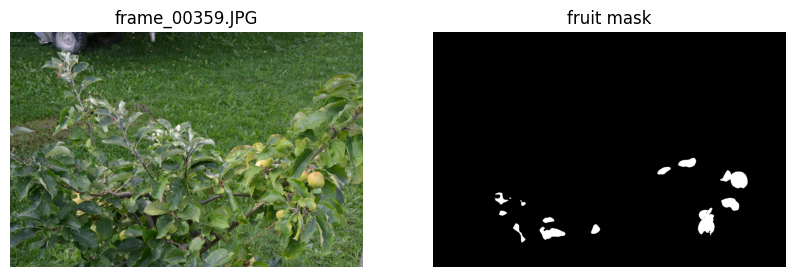

In [4]:
# ===== Cell 4: load the scene
assert CFG["scene"] is not None, "set CFG['scene'] to one of the paths printed in Cell 2"
SCENE_DIR = CFG["data_root"] / CFG["scene"]
assert SCENE_DIR.is_dir(), f"{SCENE_DIR} does not exist - pick a scene printed by Cell 2"
RUN_DIR = CFG["out_root"] / (CFG["scene"].replace("/", "__") + f"__{CFG['semantic_dir']}__{CFG['preset']}")
RUN_DIR.mkdir(parents=True, exist_ok=True)
ds = SceneData(SCENE_DIR, CFG["semantic_dir"], CFG["downscale"], CFG["images_on_gpu"], cache_dir=CFG["out_root"] / "cache")
print(f"\n>>> {TREE}: {ds.N} images | run folder: {RUN_DIR.name}")

k = 0
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(ds.images[k].cpu().numpy()); ax[0].set_title(ds.names[k])
ax[1].imshow(ds.masks[k].cpu().numpy(), cmap="gray"); ax[1].set_title("fruit mask")
for a in ax: a.axis("off")
plt.show()

In [5]:
# ===== Cell 5: network building blocks
class _TruncExp(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return torch.exp(x)
    @staticmethod
    def backward(ctx, g):
        (x,) = ctx.saved_tensors
        return g * torch.exp(x.clamp(max=15))
trunc_exp = _TruncExp.apply

def contract(x):
    """mip-NeRF 360 contraction with L-inf norm (nerfacto): R^3 -> [-2, 2]^3."""
    mag = x.abs().amax(-1, keepdim=True).clamp_min(1e-9)
    return torch.where(mag < 1, x, (2 - 1 / mag) * (x / mag))

def sh_encode(d):
    """Real spherical harmonics, degree 4 (16 coefficients)."""
    x, y, z = d.unbind(-1)
    xx, yy, zz = x * x, y * y, z * z
    xy, yz, xz = x * y, y * z, x * z
    return torch.stack([
        0.28209479177387814 * torch.ones_like(x),
        -0.48860251190291987 * y, 0.48860251190291987 * z, -0.48860251190291987 * x,
        1.0925484305920792 * xy, -1.0925484305920792 * yz, 0.94617469575755997 * zz - 0.31539156525251999,
        -1.0925484305920792 * xz, 0.54627421529603959 * (xx - yy),
        0.59004358992664352 * y * (-3 * xx + yy), 2.8906114426405538 * xy * z,
        0.45704579946446572 * y * (1 - 5 * zz), 0.3731763325901154 * z * (5 * zz - 3),
        0.45704579946446572 * x * (1 - 5 * zz), 1.4453057213202769 * z * (xx - yy),
        0.59004358992664352 * x * (-xx + 3 * yy)], -1)

class TorchHashGrid(nn.Module):
    """Multi-resolution hash encoding (Instant-NGP) in pure PyTorch. Input in [0,1]^3."""
    def __init__(self, num_levels, features_per_level, log2_hashmap_size, base_res, max_res):
        super().__init__()
        self.L, self.Fd, self.T = num_levels, features_per_level, 2 ** log2_hashmap_size
        g = math.exp((math.log(max_res) - math.log(base_res)) / max(num_levels - 1, 1))
        self.register_buffer("scales", torch.tensor([base_res * g ** l for l in range(num_levels)], dtype=torch.float32))
        self.table = nn.Parameter(torch.empty(num_levels * self.T, features_per_level).uniform_(-1e-4, 1e-4))
        self.register_buffer("primes", torch.tensor([1, 2654435761, 805459861], dtype=torch.int64))
        self.register_buffer("corners", torch.tensor([[(c >> 2) & 1, (c >> 1) & 1, c & 1] for c in range(8)], dtype=torch.int64))
        self.out_dim = num_levels * features_per_level

    def forward(self, x):
        outs = []
        cb = self.corners.bool()
        for l in range(self.L):
            pos = x * self.scales[l]
            p0 = torch.floor(pos)
            frac = (pos - p0)[:, None, :]                             # [N,1,3]
            idx = p0.long()[:, None, :] + self.corners[None]          # [N,8,3]
            h = idx * self.primes
            h = (h[..., 0] ^ h[..., 1] ^ h[..., 2]) & (self.T - 1)
            w = torch.where(cb[None], frac, 1 - frac).prod(-1)        # [N,8]
            f = F.embedding(h + l * self.T, self.table)               # [N,8,F]
            outs.append((f * w[..., None]).sum(1))
        return torch.cat(outs, -1)

class TcnnHashGrid(nn.Module):
    def __init__(self, num_levels, features_per_level, log2_hashmap_size, base_res, max_res):
        super().__init__()
        import tinycudann as tcnn
        g = math.exp((math.log(max_res) - math.log(base_res)) / max(num_levels - 1, 1))
        self.enc = tcnn.Encoding(3, {"otype": "HashGrid", "n_levels": num_levels, "n_features_per_level": features_per_level,
                                     "log2_hashmap_size": log2_hashmap_size, "base_resolution": base_res, "per_level_scale": g})
        self.out_dim = num_levels * features_per_level
    def forward(self, x):
        return self.enc(x).float()

def make_hash_grid(num_levels, features_per_level, log2_hashmap_size, base_res, max_res):
    if CFG["use_tcnn"] and DEVICE.type == "cuda":
        try:
            return TcnnHashGrid(num_levels, features_per_level, log2_hashmap_size, base_res, max_res)
        except ImportError:
            pass
    return TorchHashGrid(num_levels, features_per_level, log2_hashmap_size, base_res, max_res)

def mlp(in_dim, hidden, n_hidden_layers, out_dim):
    layers, d = [], in_dim
    for _ in range(n_hidden_layers):
        layers += [nn.Linear(d, hidden), nn.ReLU(inplace=True)]
        d = hidden
    layers.append(nn.Linear(d, out_dim))
    return nn.Sequential(*layers)

def _to_unit(x):
    return ((contract(x) + 2.0) / 4.0).clamp(0.0, 1.0)

class ProposalField(nn.Module):
    """Small density-only hash field used by the proposal sampler (nerfacto)."""
    def __init__(self, num_levels, log2_hashmap_size, max_res, hidden):
        super().__init__()
        self.enc = make_hash_grid(num_levels, 2, log2_hashmap_size, 16, max_res)
        self.mlp = mlp(self.enc.out_dim, hidden, 1, 1)
    def forward(self, x):
        return trunc_exp(self.mlp(self.enc(_to_unit(x))).float().squeeze(-1) - 1.0)

class FruitNeRFField(nn.Module):
    """Density field + Appearance field + Fruit field (paper Fig. 6)."""
    def __init__(self, P, num_images):
        super().__init__()
        self.enc = make_hash_grid(P["num_levels"], P["features_per_level"], P["log2_hashmap_size"], P["base_res"], P["max_res"])
        self.geo_dim = P["geo_feat_dim"]
        self.density_mlp = mlp(self.enc.out_dim, P["hidden_dim"], 1, 1 + self.geo_dim)
        self.app_emb = nn.Embedding(num_images, P["appearance_dim"])
        nn.init.normal_(self.app_emb.weight, 0, 0.01)
        self.color_mlp = mlp(16 + self.geo_dim + P["appearance_dim"], P["hidden_dim_color"], 2, 3)
        # Fruit Field: input = density feature vector only (view-independent)
        self.fruit_mlp = nn.Sequential(mlp(self.geo_dim, P["sem_hidden"], P["sem_layers"] - 1, P["sem_out"]),
                                       nn.ReLU(inplace=True), nn.Linear(P["sem_out"], 1))

    def density(self, x):
        h = self.density_mlp(self.enc(_to_unit(x))).float()
        return trunc_exp(h[..., 0] - 1.0), h[..., 1:]

    def color(self, geo, d, cam_idx=None):
        if cam_idx is None:
            emb = self.app_emb.weight.mean(0, keepdim=True).expand(geo.shape[0], -1)
        else:
            emb = self.app_emb(cam_idx)
        return torch.sigmoid(self.color_mlp(torch.cat([sh_encode(d), geo, emb], -1)).float())

    def fruit_logit(self, geo):
        return self.fruit_mlp(geo.detach()).float().squeeze(-1)   # detach: semantic loss never reaches density

In [6]:
# ===== Cell 6: sampling, rendering, losses, model
def _spacing(t):      return torch.where(t < 1, t / 2, 1 - 1 / (2 * t))           # UniformLinDisp piecewise
def _spacing_inv(s):  return torch.where(s < 0.5, 2 * s, 1 / (2 - 2 * s))

def s_to_t(s, near, far):
    gn, gf = _spacing(near), _spacing(far)
    return _spacing_inv(s * gf + (1 - s) * gn)

def uniform_bins(R, n, train, device):
    bins = torch.linspace(0, 1, n + 1, device=device).expand(R, n + 1)
    if train:
        r = torch.rand(R, 1, device=device)
        c = (bins[:, 1:] + bins[:, :-1]) / 2
        upper = torch.cat([c, bins[:, -1:]], -1)
        lower = torch.cat([bins[:, :1], c], -1)
        bins = lower + (upper - lower) * r
    return bins.contiguous()

def sample_pdf(bins, weights, n, train, pad=0.01, eps=1e-5):
    weights = weights + pad
    wsum = weights.sum(-1, keepdim=True)
    padding = F.relu(eps - wsum)
    weights = weights + padding / weights.shape[-1]
    wsum = wsum + padding
    cdf = torch.clamp(torch.cumsum(weights / wsum, -1), max=1.0)
    cdf = torch.cat([torch.zeros_like(cdf[:, :1]), cdf], -1).contiguous()
    nb, R = n + 1, bins.shape[0]
    u = torch.linspace(0.0, 1.0 - 1.0 / nb, nb, device=bins.device).expand(R, nb)
    u = u + (torch.rand(R, 1, device=bins.device) / nb if train else 0.5 / nb)
    u = u.contiguous()
    inds = torch.searchsorted(cdf, u, right=True)
    below = (inds - 1).clamp(0, bins.shape[-1] - 1)
    above = inds.clamp(0, bins.shape[-1] - 1)
    c0, c1 = cdf.gather(-1, below), cdf.gather(-1, above)
    b0, b1 = bins.gather(-1, below), bins.gather(-1, above)
    t = torch.clip(torch.nan_to_num((u - c0) / (c1 - c0), 0.0), 0.0, 1.0)
    return (b0 + t * (b1 - b0)).detach().contiguous()

def compute_weights(sigma, deltas):
    dd = sigma * deltas
    alpha = 1 - torch.exp(-dd)
    trans = torch.exp(-torch.cat([torch.zeros_like(dd[:, :1]), torch.cumsum(dd[:, :-1], -1)], -1))
    return torch.nan_to_num(alpha * trans)

def _outer(t0s, t0e, t1s, t1e, y1):
    cy1 = torch.cat([torch.zeros_like(y1[..., :1]), torch.cumsum(y1, -1)], -1)
    lo = (torch.searchsorted(t1s.contiguous(), t0s.contiguous(), right=True) - 1).clamp(0, y1.shape[-1] - 1)
    hi = torch.searchsorted(t1e.contiguous(), t0e.contiguous(), right=True).clamp(0, y1.shape[-1] - 1)
    return torch.take_along_dim(cy1[..., 1:], hi, -1) - torch.take_along_dim(cy1[..., :-1], lo, -1)

def interlevel_loss(w_list, bins_list):
    """mip-NeRF 360 proposal loss (trains the proposal networks)."""
    c, w = bins_list[-1].detach(), w_list[-1].detach()
    loss = 0.0
    for b, wp in zip(bins_list[:-1], w_list[:-1]):
        w_outer = _outer(c[:, :-1], c[:, 1:], b[:, :-1], b[:, 1:], wp)
        loss = loss + (torch.clamp(w - w_outer, min=0) ** 2 / (w + 1e-7)).mean()
    return loss

def distortion_loss(bins, w):
    mids = 0.5 * (bins[:, 1:] + bins[:, :-1])
    iv = bins[:, 1:] - bins[:, :-1]
    pair = (w[:, :, None] * w[:, None, :] * (mids[:, :, None] - mids[:, None, :]).abs()).sum((-1, -2))
    return (pair + (w ** 2 * iv).sum(-1) / 3).mean()

class FruitNeRF(nn.Module):
    def __init__(self, P, num_images):
        super().__init__()
        self.P = P
        self.field = FruitNeRFField(P, num_images)
        self.props = nn.ModuleList([ProposalField(**c) for c in P["prop_nets"]])

    def forward(self, o, d, cam_idx=None, anneal=1.0, train=False):
        P, R, dev = self.P, o.shape[0], o.device
        near = torch.full((R, 1), P["near"], device=dev)
        far = torch.full((R, 1), P["far"], device=dev)
        n_samples = list(P["prop_samples"]) + [P["nerf_samples"]]
        bins_list, w_list = [], []
        bins = uniform_bins(R, n_samples[0], train, dev)
        w = None
        for lvl in range(len(n_samples)):
            if lvl > 0:
                bins = sample_pdf(bins, torch.pow(w.detach(), anneal), n_samples[lvl], train)
            t = s_to_t(bins, near, far)
            mids = 0.5 * (t[:, 1:] + t[:, :-1])
            deltas = t[:, 1:] - t[:, :-1]
            pts = (o[:, None, :] + d[:, None, :] * mids[..., None]).reshape(-1, 3)
            if lvl < len(self.props):
                sigma = self.props[lvl](pts).reshape(R, -1)
                w = compute_weights(sigma, deltas)
                bins_list.append(bins); w_list.append(w)

        M = mids.shape[1]
        sigma, geo = self.field.density(pts)
        sigma = sigma.reshape(R, M)
        w = compute_weights(sigma, deltas)
        dirs = d[:, None, :].expand(R, M, 3).reshape(-1, 3)
        cam = cam_idx[:, None].expand(R, M).reshape(-1) if cam_idx is not None else None
        rgb = self.field.color(geo, dirs, cam).reshape(R, M, 3)
        fruit = self.field.fruit_logit(geo).reshape(R, M)

        acc = w.sum(-1, keepdim=True)
        comp_rgb = (w[..., None] * rgb).sum(1) + rgb[:, -1] * (1 - acc)   # 'last_sample' background (nerfacto)
        fruit_logit = (w.detach() * fruit).sum(-1)                          # paper Eq. (2)
        depth = (w * mids).sum(-1) / (acc.squeeze(-1) + 1e-10)
        out = dict(rgb=comp_rgb, fruit_logit=fruit_logit, acc=acc.squeeze(-1), depth=depth)
        if train:
            out["bins_list"] = bins_list + [bins]
            out["w_list"] = w_list + [w]
        return out

def build_model(P, num_images):
    m = FruitNeRF(P, num_images).to(DEVICE)
    kind = type(m.field.enc).__name__
    print(f"FruitNeRF built ({kind}), params: {sum(p.numel() for p in m.parameters()) / 1e6:.1f} M")
    return m

In [7]:
# ===== Cell 7: training (camera optimizer, split, optimizers)
def _hat(v):
    z = torch.zeros_like(v[:, 0])
    return torch.stack([torch.stack([z, -v[:, 2], v[:, 1]], -1),
                        torch.stack([v[:, 2], z, -v[:, 0]], -1),
                        torch.stack([-v[:, 1], v[:, 0], z], -1)], 1)

def exp_map_SO3xR3(tangent):
    """nerfstudio SO3xR3: tangent[:, :3] = translation, tangent[:, 3:] = axis-angle rotation -> [N,3,4]."""
    log_rot = tangent[:, 3:]
    ang = torch.clamp((log_rot * log_rot).sum(-1), 1e-4).sqrt()
    fac1 = torch.sin(ang) / ang
    fac2 = (1.0 - torch.cos(ang)) / (ang * ang)
    K = _hat(log_rot)
    R = torch.eye(3, device=tangent.device)[None] + fac1[:, None, None] * K + fac2[:, None, None] * (K @ K)
    return torch.cat([R, tangent[:, :3, None]], -1)

class CameraOptimizer(nn.Module):
    """Per-image pose refinement (nerfstudio CameraOptimizer, mode SO3xR3)."""
    def __init__(self, num_cameras):
        super().__init__()
        self.pose_adjustment = nn.Parameter(torch.zeros(num_cameras, 6))
    def apply(self, o, d, cam_idx):
        T = exp_map_SO3xR3(self.pose_adjustment[cam_idx])
        return o + T[:, :3, 3], torch.bmm(T[:, :3, :3], d[..., None]).squeeze(-1)

def train_eval_split(n, frac):
    """nerfstudio split: evenly spaced training indices, the rest is held out."""
    n_train = int(math.ceil(n * frac))
    i_train = np.unique(np.linspace(0, n - 1, n_train).round().astype(int))
    i_eval = np.setdiff1d(np.arange(n), i_train)
    return i_train, i_eval

def anneal_value(step, P):
    x = min(max(step / P["prop_anneal_iters"], 0.0), 1.0)
    b = 10.0
    return (b * x) / ((b - 1) * x + 1)

def psnr(mse):
    return -10.0 * math.log10(max(mse, 1e-10))

def _exp_decay(lr0, lr_final, steps):
    if lr_final is None:
        return lambda s: 1.0
    return lambda s: (lr_final / lr0) ** min(s / steps, 1.0)

def make_optimizers(model, cam_opt, P):
    Opt = torch.optim.RAdam if P["optimizer"] == "radam" else torch.optim.Adam
    groups = [
        dict(params=list(model.field.parameters()), lr=P["fields_lr"], eps=1e-15),
        dict(params=list(model.props.parameters()), lr=P["prop_lr"], eps=1e-15),
    ]
    opt = Opt(groups)
    cam = Opt(cam_opt.parameters(), lr=P["cam_lr"], eps=P["cam_eps"], weight_decay=P["cam_wd"])
    cam_final, cam_steps = P["cam_lr_final"], P["cam_decay_steps"]
    if cam_final is None:          # nerfstudio 0.3.2 CameraOptimizerConfig default scheduler (approx.)
        cam_final, cam_steps = 1e-6 * P["cam_lr"] / 6e-4, 10_000
    sched = torch.optim.lr_scheduler.LambdaLR(opt, [
        _exp_decay(P["fields_lr"], P["fields_lr_final"], P["fields_decay_steps"]),
        _exp_decay(P["prop_lr"], P["prop_lr_final"], P["prop_decay_steps"])])
    cam_sched = torch.optim.lr_scheduler.LambdaLR(cam, _exp_decay(P["cam_lr"], cam_final, cam_steps))
    return opt, sched, cam, cam_sched

def train(model, ds, P, run_dir, max_steps, B, log_every=250, ckpt_every=5000):
    i_train, i_eval = train_eval_split(ds.N, P["train_split_fraction"])
    ds.i_train, ds.i_eval = i_train, i_eval
    train_idx = torch.as_tensor(i_train, device=ds.store)
    print(f"train images: {len(i_train)} | held-out: {len(i_eval)} | rays/batch {B} | "
          f"optimizer {P['optimizer']} | mixed precision {P['mixed_precision']}")
    cam_opt = CameraOptimizer(ds.N).to(DEVICE)
    model.cam_opt = cam_opt
    opt, sched, copt, csched = make_optimizers(model, cam_opt, P)
    use_amp = P["mixed_precision"] and DEVICE.type == "cuda"
    amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)
    hist = {"step": [], "loss": [], "psnr": [], "sem": []}
    model.train()
    t0 = t_last = time.time()
    for step in range(max_steps + 1):
        g = ds.store
        i = train_idx[torch.randint(0, len(train_idx), (B,), device=g)]
        v = torch.randint(0, ds.H, (B,), device=g)
        u = torch.randint(0, ds.W, (B,), device=g)
        rgb_gt = (ds.images[i, v, u].float() / 255.0).to(DEVICE)
        m_gt = ds.masks[i, v, u].float().to(DEVICE)
        i, u, v = i.to(DEVICE), u.to(DEVICE).float(), v.to(DEVICE).float()
        o, d = get_rays(ds, i, u, v)
        o, d = cam_opt.apply(o, d, i)
        with torch.autocast("cuda", dtype=amp_dtype, enabled=use_amp):
            out = model(o, d, i, anneal=anneal_value(step, P), train=True)
        l_rgb = F.mse_loss(out["rgb"].float(), rgb_gt)                                  # Eq. (4)
        l_sem = F.binary_cross_entropy_with_logits(out["fruit_logit"].float(), m_gt)    # Eq. (5)
        l_int = interlevel_loss([w.float() for w in out["w_list"]], out["bins_list"])
        l_dst = distortion_loss(out["bins_list"][-1], out["w_list"][-1].float())
        loss = l_rgb + l_sem + P["interlevel_mult"] * l_int + P["distortion_mult"] * l_dst   # Eq. (6)
        opt.zero_grad(set_to_none=True); copt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.step(copt); scaler.update()
        sched.step(); csched.step()
        if step % log_every == 0:
            now = time.time()
            its = log_every / (now - t_last) if step > 0 else 0.0
            t_last = now
            eta = (max_steps - step) / its / 60 if its > 0 else float("nan")
            p = psnr(l_rgb.item())
            hist["step"].append(step); hist["loss"].append(loss.item()); hist["psnr"].append(p); hist["sem"].append(l_sem.item())
            print(f"step {step:6d}/{max_steps} | psnr {p:5.2f} | sem {l_sem.item():.4f} | "
                  f"{its:4.1f} it/s | elapsed {(now - t0) / 60:5.1f} min | ETA {eta:5.1f} min", flush=True)
        if step > 0 and (step % ckpt_every == 0 or step == max_steps):
            save_ckpt(model, ds, P, run_dir / "model.pt", step)
            print(f"  checkpoint saved @ {step}", flush=True)
    print(f"training done in {(time.time() - t0) / 60:.1f} min")
    return hist

def save_ckpt(model, ds, P, path, step):
    torch.save(dict(model=model.state_dict(), P=P, num_images=ds.N, T=ds.T, scale=ds.scale, step=step,
                    i_train=getattr(ds, "i_train", None), i_eval=getattr(ds, "i_eval", None)), path)

def load_ckpt(path):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    m = build_model(ck["P"], ck["num_images"])
    sd = ck["model"]
    if any(k.startswith("cam_opt.") for k in sd):
        m.cam_opt = CameraOptimizer(ck["num_images"]).to(DEVICE)
    m.load_state_dict(sd)
    m.eval()
    return m, ck

In [8]:
# ===== Cell 8: train (or load a FINISHED model of this tree)
P = dict(PRESETS[CFG["preset"]])
MAX_STEPS = CFG["max_steps"] or P["max_steps"]
ckpt_path = RUN_DIR / "model.pt"
done = False
if ckpt_path.exists():
    _ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    done = _ck["step"] >= MAX_STEPS and _ck["num_images"] == ds.N
    print(f"found checkpoint: step {_ck['step']} / {MAX_STEPS}, {_ck['num_images']} images -> "
          f"{'COMPLETE, loading it' if done else 'incomplete -> training from scratch'}")
if done:
    model, ck = load_ckpt(ckpt_path)
    ds.i_train, ds.i_eval = ck.get("i_train"), ck.get("i_eval")
else:
    seed_everything(CFG["seed"])
    model = build_model(P, ds.N)
    hist = train(model, ds, P, RUN_DIR, MAX_STEPS, CFG["rays_per_batch"] or P["rays_per_batch"])
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist["step"], hist["psnr"]); ax[0].set_title("train PSNR"); ax[0].set_xlabel("step")
    ax[1].plot(hist["step"], hist["sem"]); ax[1].set_title("semantic BCE"); ax[1].set_yscale("log"); ax[1].set_xlabel("step")
    plt.show()
print(f">>> model ready for {TREE}")

found checkpoint: step 20000 / 30000, 345 images -> incomplete -> training from scratch
FruitNeRF built (TorchHashGrid), params: 19.4 M
train images: 311 | held-out: 34 | rays/batch 4096 | optimizer adam | mixed precision True


/tmp/ipykernel_580185/3342796811.py:75: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and amp_dtype == torch.float16)


step      0/30000 | psnr 11.31 | sem 0.7591 |  0.0 it/s | elapsed   0.1 min | ETA   nan min


KeyboardInterrupt: 

In [9]:
def _set_sched_step(sched, step):
    """Put a LambdaLR at `step` so the learning rate continues its decay instead of restarting."""
    sched.last_epoch = step
    for g, base, lam in zip(sched.optimizer.param_groups, sched.base_lrs, sched.lr_lambdas):
        g["lr"] = base * lam(step)

def train(model, ds, P, run_dir, max_steps, B, log_every=250, ckpt_every=2000,
          start_step=0, resume_state=None):
    resuming = resume_state is not None

    # --- split: reuse the saved one when resuming, so held-out images stay held out
    if resuming and getattr(ds, "i_train", None) is not None:
        i_train, i_eval = ds.i_train, ds.i_eval
    else:
        i_train, i_eval = train_eval_split(ds.N, P["train_split_fraction"])
        ds.i_train, ds.i_eval = i_train, i_eval
    train_idx = torch.as_tensor(i_train, device=ds.store)
    print(f"train images: {len(i_train)} | held-out: {len(i_eval)} | rays/batch {B} | "
          f"optimizer {P['optimizer']} | mixed precision {P['mixed_precision']}")

    # --- camera optimizer: keep the refined poses loaded from the checkpoint
    cam_opt = getattr(model, "cam_opt", None)
    if cam_opt is None:
        cam_opt = CameraOptimizer(ds.N).to(DEVICE)
        model.cam_opt = cam_opt

    opt, sched, copt, csched = make_optimizers(model, cam_opt, P)
    use_amp = P["mixed_precision"] and DEVICE.type == "cuda"
    amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp and amp_dtype == torch.float16)
    hist = {"step": [], "loss": [], "psnr": [], "sem": []}

    # --- restore training state
    first = 0
    if resuming:
        first = start_step + 1                      # checkpoint step N means iteration N already ran
        if "opt" in resume_state:
            opt.load_state_dict(resume_state["opt"])
            copt.load_state_dict(resume_state["copt"])
            scaler.load_state_dict(resume_state["scaler"])
            print("restored optimizer state")
        else:
            print("old checkpoint without optimizer state: Adam restarts, expect a short PSNR dip")
        hist = resume_state.get("hist") or hist
        print(f"resuming at step {first} / {max_steps}")
    _set_sched_step(sched, first)
    _set_sched_step(csched, first)

    def _save(step):
        save_ckpt(model, ds, P, run_dir / "model.pt", step, extra=dict(
            opt=opt.state_dict(), copt=copt.state_dict(), scaler=scaler.state_dict(), hist=hist))

    model.train()
    t0 = t_last = time.time()
    step = first - 1
    try:
        for step in range(first, max_steps + 1):
            g = ds.store
            i = train_idx[torch.randint(0, len(train_idx), (B,), device=g)]
            v = torch.randint(0, ds.H, (B,), device=g)
            u = torch.randint(0, ds.W, (B,), device=g)
            rgb_gt = (ds.images[i, v, u].float() / 255.0).to(DEVICE)
            m_gt = ds.masks[i, v, u].float().to(DEVICE)
            i, u, v = i.to(DEVICE), u.to(DEVICE).float(), v.to(DEVICE).float()
            o, d = get_rays(ds, i, u, v)
            o, d = cam_opt.apply(o, d, i)
            with torch.autocast("cuda", dtype=amp_dtype, enabled=use_amp):
                out = model(o, d, i, anneal=anneal_value(step, P), train=True)
            l_rgb = F.mse_loss(out["rgb"].float(), rgb_gt)                                  # Eq. (4)
            l_sem = F.binary_cross_entropy_with_logits(out["fruit_logit"].float(), m_gt)    # Eq. (5)
            l_int = interlevel_loss([w.float() for w in out["w_list"]], out["bins_list"])
            l_dst = distortion_loss(out["bins_list"][-1], out["w_list"][-1].float())
            loss = l_rgb + l_sem + P["interlevel_mult"] * l_int + P["distortion_mult"] * l_dst   # Eq. (6)
            opt.zero_grad(set_to_none=True); copt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.step(copt); scaler.update()
            sched.step(); csched.step()

            if step % log_every == 0:
                now = time.time()
                its = log_every / (now - t_last) if step > first else 0.0
                t_last = now
                eta = (max_steps - step) / its / 60 if its > 0 else float("nan")
                p = psnr(l_rgb.item())
                hist["step"].append(step); hist["loss"].append(loss.item()); hist["psnr"].append(p); hist["sem"].append(l_sem.item())
                print(f"step {step:6d}/{max_steps} | psnr {p:5.2f} | sem {l_sem.item():.4f} | "
                      f"{its:4.1f} it/s | elapsed {(now - t0) / 60:5.1f} min | ETA {eta:5.1f} min", flush=True)

            if step > 0 and (step % ckpt_every == 0 or step == max_steps):
                _save(step)
                print(f"  checkpoint saved @ {step}", flush=True)

    except KeyboardInterrupt:                       # stopping the cell keeps your progress
        if step >= first:
            _save(step)
            print(f"\ninterrupted: checkpoint saved @ {step}, re-run Cell 8 to resume", flush=True)
        raise

    print(f"training done in {(time.time() - t0) / 60:.1f} min")
    return hist

def save_ckpt(model, ds, P, path, step, extra=None):
    ck = dict(model=model.state_dict(), P=P, num_images=ds.N, T=ds.T, scale=ds.scale, step=step,
              i_train=getattr(ds, "i_train", None), i_eval=getattr(ds, "i_eval", None))
    if extra:
        ck.update(extra)
    tmp = Path(str(path) + ".tmp")
    torch.save(ck, tmp)
    os.replace(tmp, path)                           # atomic: a crash mid-save can't corrupt model.pt

def load_ckpt(path):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    m = build_model(ck["P"], ck["num_images"])
    sd = ck["model"]
    if any(k.startswith("cam_opt.") for k in sd):
        m.cam_opt = CameraOptimizer(ck["num_images"]).to(DEVICE)
    m.load_state_dict(sd)
    m.eval()
    return m, ck

found checkpoint: step 20000 / 30000, 345 images (dataset has 345) -> RESUME
FruitNeRF built (TorchHashGrid), params: 19.4 M
train images: 311 | held-out: 34 | rays/batch 4096 | optimizer adam | mixed precision True
restored optimizer state
resuming at step 20001 / 30000
step  20250/30000 | psnr 19.76 | sem 0.0733 |  0.6 it/s | elapsed   7.0 min | ETA 274.1 min
step  20500/30000 | psnr 19.64 | sem 0.0716 |  0.6 it/s | elapsed  14.1 min | ETA 267.6 min
step  20750/30000 | psnr 20.01 | sem 0.0762 |  0.6 it/s | elapsed  21.1 min | ETA 259.7 min
step  21000/30000 | psnr 19.79 | sem 0.0803 |  0.6 it/s | elapsed  28.1 min | ETA 254.0 min
step  21250/30000 | psnr 19.71 | sem 0.0734 |  0.6 it/s | elapsed  35.2 min | ETA 246.2 min
step  21500/30000 | psnr 19.71 | sem 0.0690 |  0.6 it/s | elapsed  42.2 min | ETA 239.7 min
step  21750/30000 | psnr 19.51 | sem 0.0858 |  0.6 it/s | elapsed  49.3 min | ETA 231.8 min
step  22000/30000 | psnr 20.04 | sem 0.0698 |  0.6 it/s | elapsed  56.3 min | ETA 22

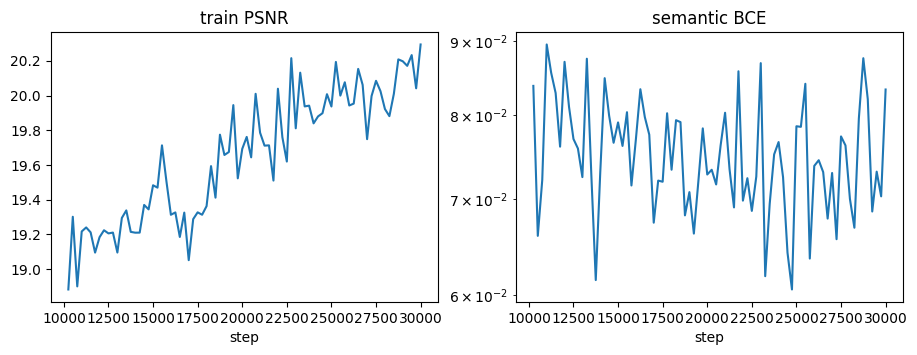

>>> model ready for tree_01


In [10]:
# ===== Cell 8: train, resume an unfinished run, or load a finished model of this tree
P = dict(PRESETS[CFG["preset"]])
MAX_STEPS = CFG["max_steps"] or P["max_steps"]
RAYS = CFG["rays_per_batch"] or P["rays_per_batch"]
ckpt_path = RUN_DIR / "model.pt"

status, ck = "fresh", None
if ckpt_path.exists():
    ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    if ck["num_images"] != ds.N:
        status = "mismatch"          # different dataset, can't reuse
    elif ck["step"] >= MAX_STEPS:
        status = "complete"
    else:
        status = "resume"
    print(f"found checkpoint: step {ck['step']} / {MAX_STEPS}, {ck['num_images']} images "
          f"(dataset has {ds.N}) -> {status.upper()}")

if status == "complete":
    model, ck = load_ckpt(ckpt_path)
    ds.i_train, ds.i_eval = ck.get("i_train"), ck.get("i_eval")
    hist = ck.get("hist")

else:
    if status == "resume":
        model, ck = load_ckpt(ckpt_path)                        # restores weights
        ds.i_train, ds.i_eval = ck.get("i_train"), ck.get("i_eval")  # keep the SAME held-out split
        start_step, resume_state = ck["step"], ck
    else:
        if status == "mismatch":                                # keep the old run instead of overwriting it
            ckpt_path.rename(RUN_DIR / f"model_stale_{ck['num_images']}img_step{ck['step']}.pt")
        seed_everything(CFG["seed"])
        model = build_model(P, ds.N)
        start_step, resume_state = 0, None
    del ck

    hist = train(model, ds, P, RUN_DIR, MAX_STEPS, RAYS,
                 start_step=start_step, resume_state=resume_state)

if hist:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist["step"], hist["psnr"]); ax[0].set_title("train PSNR"); ax[0].set_xlabel("step")
    ax[1].plot(hist["step"], hist["sem"]); ax[1].set_title("semantic BCE"); ax[1].set_yscale("log"); ax[1].set_xlabel("step")
    plt.show()
print(f">>> model ready for {TREE}")

PSNR view 5: 17.67 dB (held-out view)


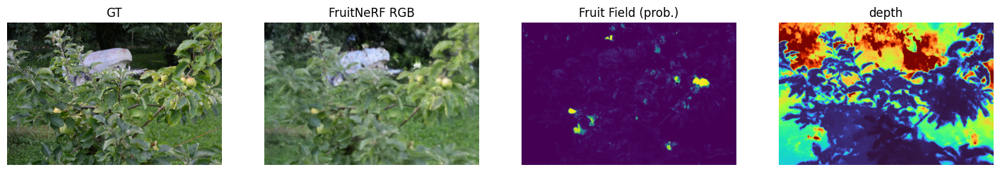

In [11]:
# ===== Cell 9: render a view (RGB / fruit field / depth)
@torch.no_grad()
def render_view(model, ds, idx, chunk=8192):
    model.eval()
    vv, uu = torch.meshgrid(torch.arange(ds.H, device=DEVICE), torch.arange(ds.W, device=DEVICE), indexing="ij")
    uu, vv = uu.reshape(-1).float(), vv.reshape(-1).float()
    ii = torch.full_like(uu, idx, dtype=torch.long)
    rgb, sem, dep = [], [], []
    for s in range(0, uu.numel(), chunk):
        o, d = get_rays(ds, ii[s:s + chunk], uu[s:s + chunk], vv[s:s + chunk])
        out = model(o, d, None, train=False)
        rgb.append(out["rgb"]); sem.append(torch.sigmoid(out["fruit_logit"])); dep.append(out["depth"])
    rgb = torch.cat(rgb).reshape(ds.H, ds.W, 3).clamp(0, 1).cpu().numpy()
    sem = torch.cat(sem).reshape(ds.H, ds.W).cpu().numpy()
    dep = torch.cat(dep).reshape(ds.H, ds.W).cpu().numpy()
    return rgb, sem, dep

i_eval = getattr(ds, "i_eval", None)
i_eval = [] if i_eval is None else i_eval
view = int(i_eval[0]) if len(i_eval) else 0
rgb, sem, dep = render_view(model, ds, view)
gt = ds.images[view].cpu().numpy() / 255.0
print(f"PSNR view {view}: {psnr(float(((rgb - gt) ** 2).mean())):.2f} dB "
      f"({'held-out view' if len(i_eval) else 'training view'})")
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
for a, im, t in zip(ax, [gt, rgb, sem, dep], ["GT", "FruitNeRF RGB", "Fruit Field (prob.)", "depth"]):
    a.imshow(im, cmap=None if im.ndim == 3 else ("viridis" if t != "depth" else "turbo"),
             vmax=None if t != "depth" else np.percentile(dep, 95)); a.set_title(t); a.axis("off")
plt.show()

In [12]:
# ===== Cell 10: volume sampling / point-cloud export
def save_ply(path, pts, cols=None):
    pts = np.asarray(pts, dtype=np.float32)
    n = len(pts)
    header = f"ply\nformat binary_little_endian 1.0\nelement vertex {n}\nproperty float x\nproperty float y\nproperty float z\n"
    dt = [("x", "<f4"), ("y", "<f4"), ("z", "<f4")]
    if cols is not None:
        header += "property uchar red\nproperty uchar green\nproperty uchar blue\n"
        dt += [("r", "u1"), ("g", "u1"), ("b", "u1")]
    header += "end_header\n"
    arr = np.empty(n, dtype=dt)
    arr["x"], arr["y"], arr["z"] = pts[:, 0], pts[:, 1], pts[:, 2]
    if cols is not None:
        c = np.asarray(cols)
        c = (c * 255).round().clip(0, 255).astype(np.uint8) if c.dtype != np.uint8 else c
        arr["r"], arr["g"], arr["b"] = c[:, 0], c[:, 1], c[:, 2]
    with open(path, "wb") as f:
        f.write(header.encode()); f.write(arr.tobytes())

@torch.no_grad()
def export_point_clouds(model, bmin, bmax, res, density_thr, semantic_thr, tree_keep_frac=0.05, chunk=1 << 20):
    """Uniformly sample the Density / Appearance / Fruit fields on a res^3 grid (paper Sec. III-D)."""
    model.eval()
    bmin, bmax = [float(v) for v in bmin], [float(v) for v in bmax]
    axes = [torch.linspace(bmin[k], bmax[k], res, device=DEVICE) for k in range(3)]
    gx, gy = torch.meshgrid(axes[0], axes[1], indexing="ij")
    plane = torch.stack([gx.reshape(-1), gy.reshape(-1)], -1)
    view_dir = torch.tensor([0.0, 0.0, -1.0], device=DEVICE)
    fruit_p, fruit_c, fruit_s, tree_p, tree_c = [], [], [], [], []
    for z in tqdm(axes[2], desc="export"):
        pts_all = torch.cat([plane, z.expand(plane.shape[0], 1)], -1)
        for s in range(0, pts_all.shape[0], chunk):
            pts = pts_all[s:s + chunk]
            sigma, geo = model.field.density(pts)
            keep = sigma > density_thr
            if not keep.any():
                continue
            pts, geo = pts[keep], geo[keep]
            prob = torch.sigmoid(model.field.fruit_logit(geo))
            col = model.field.color(geo, view_dir.expand(pts.shape[0], 3), None)
            f = prob > semantic_thr
            fruit_p.append(pts[f].cpu()); fruit_c.append(col[f].cpu()); fruit_s.append(prob[f].cpu())
            t = torch.rand(pts.shape[0], device=DEVICE) < tree_keep_frac
            tree_p.append(pts[t].cpu()); tree_c.append(col[t].cpu())
    cat = lambda L, d: torch.cat(L).numpy() if L else np.zeros((0, d), np.float32)
    return dict(fruit_pts=cat(fruit_p, 3), fruit_rgb=cat(fruit_c, 3),
                fruit_prob=torch.cat(fruit_s).numpy() if fruit_s else np.zeros(0, np.float32),
                tree_pts=cat(tree_p, 3), tree_rgb=cat(tree_c, 3), spacing=max(b - a for a, b in zip(bmin, bmax)) / (res - 1))

@torch.no_grad()
def threshold_table(model, bmin, bmax, res=200, d_thrs=(1, 5, 10, 25, 50, 100, 250), s_thrs=(0.5, 0.7, 0.9)):
    """Coarse grid statistics to choose τσ and τs."""
    model.eval()
    axes = [torch.linspace(float(bmin[k]), float(bmax[k]), res, device=DEVICE) for k in range(3)]
    g = torch.stack(torch.meshgrid(*axes, indexing="ij"), -1).reshape(-1, 3)
    sig, prob = [], []
    for s in range(0, g.shape[0], 1 << 20):
        a, geo = model.field.density(g[s:s + (1 << 20)])
        sig.append(a); prob.append(torch.sigmoid(model.field.fruit_logit(geo)))
    sig, prob = torch.cat(sig), torch.cat(prob)
    print(f"density percentiles (all grid pts): " +
          ", ".join(f"p{q}={torch.quantile(sig[::max(1, sig.numel() // 5_000_000)], q / 100).item():.2f}" for q in (50, 90, 99, 99.9)))
    print("number of FRUIT points on the coarse grid:")
    print("  τσ \\ τs " + "".join(f"{s:>10}" for s in s_thrs))
    for d in d_thrs:
        print(f"  {d:>7} " + "".join(f"{int(((sig > d) & (prob > s)).sum()):>10}" for s in s_thrs))

def plot_projections(tree, fruit, title="", n_tree=60000, centers=None):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ti = np.random.choice(len(tree), min(n_tree, len(tree)), replace=False) if len(tree) else []
    for a, (i, j), lab in zip(ax, [(0, 1), (0, 2), (1, 2)], ["x-y (top)", "x-z (side)", "y-z (side)"]):
        if len(tree):
            a.scatter(tree[ti, i], tree[ti, j], s=0.2, c="green", alpha=0.3)
        if len(fruit):
            a.scatter(fruit[:, i], fruit[:, j], s=0.3, c="red")
        if centers is not None and len(centers):
            a.scatter(centers[:, i], centers[:, j], s=25, facecolors="none", edgecolors="blue")
        a.set_title(f"{title} {lab}"); a.set_aspect("equal"); a.grid(alpha=0.3)
    plt.show()

density percentiles (all grid pts): p50=0.01, p90=3.86, p99=54.51, p99.9=315.69
number of FRUIT points on the coarse grid:
  τσ \ τs        0.5       0.7       0.9
        1      22647     15251      7899
        5      11314      7375      3589
       10       7879      5096      2526
       25       4963      3300      1706
       50       3316      2259      1237
      100       2033      1445       852
      250        868       673       446


export:   0%|          | 0/256 [00:00<?, ?it/s]

preview: 1346 fruit pts, 13558 tree pts


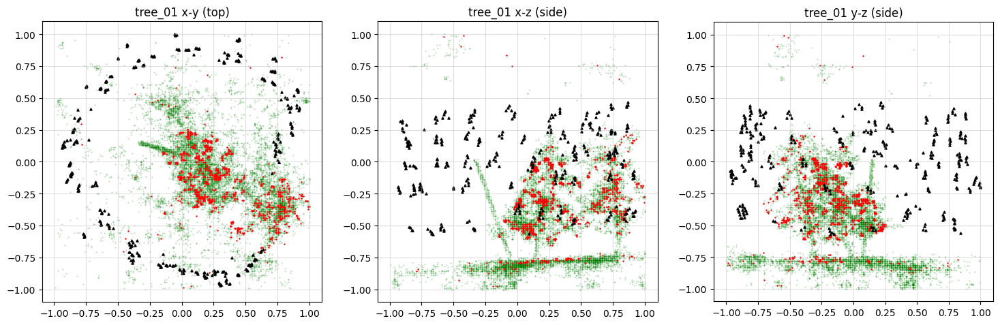

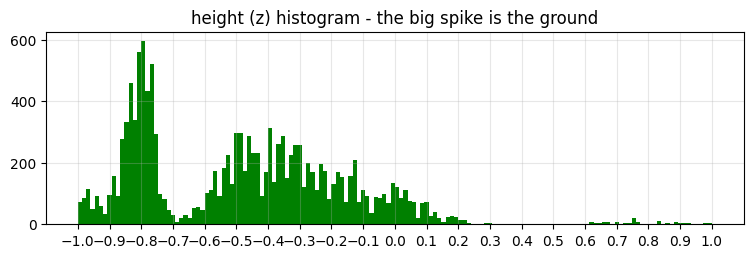

In [13]:
# ===== Cell 11: full-scene preview (read the crop box from these plots)
FULL = ((-1.0, -1.0, -1.0), (1.0, 1.0, 1.0))
threshold_table(model, *FULL, res=200)
prev = export_point_clouds(model, *FULL, 256, CFG["density_thr"], CFG["semantic_thr"], tree_keep_frac=0.3)
print(f"preview: {len(prev['fruit_pts'])} fruit pts, {len(prev['tree_pts'])} tree pts")
cams = ds.c2w[:, :3, 3].cpu().numpy()
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ti = np.random.choice(len(prev["tree_pts"]), min(80000, len(prev["tree_pts"])), replace=False)
for a_, (i, j), lab in zip(ax, [(0, 1), (0, 2), (1, 2)], ["x-y (top)", "x-z (side)", "y-z (side)"]):
    a_.scatter(prev["tree_pts"][ti, i], prev["tree_pts"][ti, j], s=0.2, c="green", alpha=0.3)
    a_.scatter(prev["fruit_pts"][:, i], prev["fruit_pts"][:, j], s=0.5, c="red")
    a_.scatter(cams[:, i], cams[:, j], s=5, c="black", marker="^")
    a_.set_title(f"{TREE} {lab}"); a_.set_aspect("equal")
    a_.set_xticks(np.arange(-1, 1.01, 0.25)); a_.set_yticks(np.arange(-1, 1.01, 0.25)); a_.grid(alpha=0.4)
plt.show()
plt.figure(figsize=(9, 2.5))
plt.hist(prev["tree_pts"][:, 2], bins=150, color="green"); plt.title("height (z) histogram - the big spike is the ground")
plt.xticks(np.arange(-1, 1.01, 0.1)); plt.grid(alpha=0.3); plt.show()

tree_01: 1 m = 0.297 units | apple diameter = 0.0223


export:   0%|          | 0/256 [00:00<?, ?it/s]

cropped preview: 14570 fruit pts


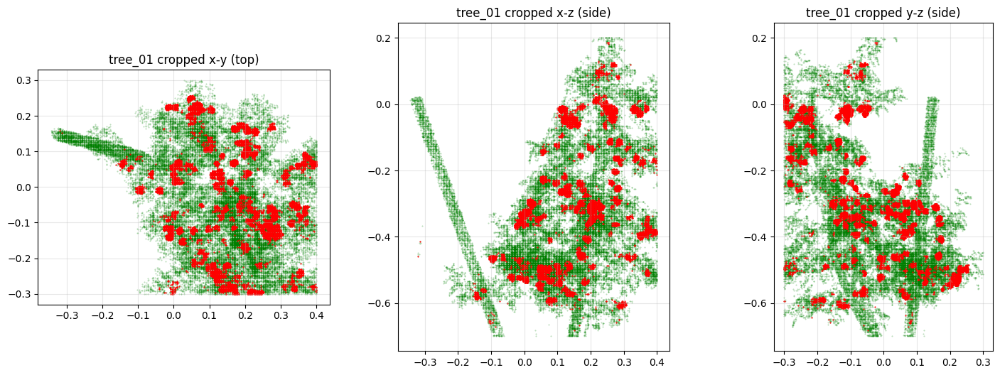

In [15]:
# ===== Cell 11b: crop box for THIS tree (the only manual step)
# Rule (same as tree_02): one crown only, bottom edge just ABOVE the ground spike, sides stop before neighbour trees.
CROP = {
    "tree_01": ((-0.35, -0.30, -0.70), (0.40, 0.30, 0.20)),        # <<< fill in after looking at Cell 11
    "tree_02": ((-0.40, -0.30, -0.55), (0.30, 0.27, 0.30)),    # used for the tree_02 result
    "tree_03": ((-1.0, -1.0, -1.0), (1.0, 1.0, 1.0)),          # <<< fill in after looking at Cell 11
}
CFG["bbox_min"], CFG["bbox_max"] = CROP[TREE]
assert tuple(CFG["bbox_min"]) != (-1.0, -1.0, -1.0), f"set the crop box for {TREE} in CROP first (see Cell 11)"

# apple size from camera distance (cameras ~3 m from the tree, paper Sec. IV-A.2)
center = (np.array(CFG["bbox_min"]) + np.array(CFG["bbox_max"])) / 2
m2n = np.median(np.linalg.norm((cams - center)[:, :2], axis=1)) / 3.0
CFG["fruit_diameter"] = 0.075 * m2n
print(f"{TREE}: 1 m = {m2n:.3f} units | apple diameter = {CFG['fruit_diameter']:.4f}")

cprev = export_point_clouds(model, CFG["bbox_min"], CFG["bbox_max"], 256, CFG["density_thr"], CFG["semantic_thr"], tree_keep_frac=0.5)
print(f"cropped preview: {len(cprev['fruit_pts'])} fruit pts")
plot_projections(cprev["tree_pts"], cprev["fruit_pts"], f"{TREE} cropped")

export:   0%|          | 0/512 [00:00<?, ?it/s]

fruit cloud: 117,172 pts | tree cloud (subsampled): 130,045 pts | grid spacing h=0.00176


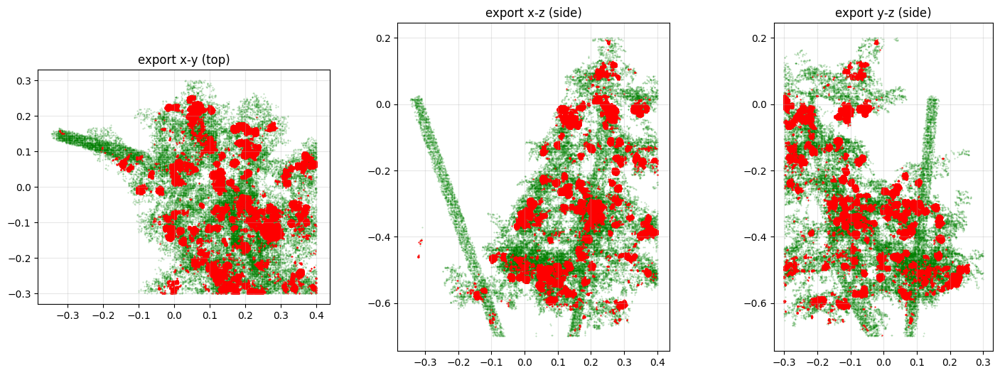

In [16]:
# ===== Cell 12: full-resolution export
pc = export_point_clouds(model, CFG["bbox_min"], CFG["bbox_max"], CFG["export_res"],
                         CFG["density_thr"], CFG["semantic_thr"], CFG["tree_keep_frac"])
print(f"fruit cloud: {len(pc['fruit_pts']):,} pts | tree cloud (subsampled): {len(pc['tree_pts']):,} pts | grid spacing h={pc['spacing']:.5f}")
save_ply(RUN_DIR / "fruit_cloud.ply", pc["fruit_pts"], pc["fruit_rgb"])
save_ply(RUN_DIR / "tree_cloud.ply", pc["tree_pts"], pc["tree_rgb"])
np.savez(RUN_DIR / "clouds.npz", **pc)
plot_projections(pc["tree_pts"], pc["fruit_pts"], "export")

In [17]:
# ===== Cell 13: cascaded clustering / fruit counting
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from scipy.spatial import cKDTree, ConvexHull
from scipy.spatial.distance import directed_hausdorff
from scipy.optimize import linear_sum_assignment

def voxel_downsample(pts, vs):
    key = np.floor(pts / vs).astype(np.int64)
    _, inv, cnt = np.unique(key, axis=0, return_inverse=True, return_counts=True)
    inv = inv.reshape(-1)
    return np.stack([np.bincount(inv, weights=pts[:, k]) / cnt for k in range(3)], 1)

def radius_outlier_removal(pts, radius, min_nb):
    n = cKDTree(pts).query_ball_point(pts, radius, return_length=True)
    return pts[n >= min_nb]

def hull_volume(p):
    if len(p) < 5:
        return 0.0
    try:
        return float(ConvexHull(p).volume)
    except Exception:
        return 0.0

def main_extent(p):
    """Largest extent along the principal axis (robust 2-98 percentile)."""
    q = p - p.mean(0)
    if len(q) < 3:
        return 0.0
    ax = np.linalg.svd(q[: min(len(q), 20000)], full_matrices=False)[2][0]
    proj = q @ ax
    return float(np.percentile(proj, 98) - np.percentile(proj, 2))

def fib_sphere(n, r):
    i = np.arange(n) + 0.5
    phi = np.arccos(1 - 2 * i / n); th = np.pi * (1 + 5 ** 0.5) * i
    return r * np.stack([np.cos(th) * np.sin(phi), np.sin(th) * np.sin(phi), np.cos(phi)], 1)

def count_fruits(pts, h, C, verbose=True, rng=None):
    """Paper Sec. III-E. pts: fruit point cloud, h: grid spacing (sets all distance scales)."""
    rng = np.random.default_rng(0) if rng is None else rng     # deterministic counts
    info = {}
    p = voxel_downsample(pts, h)
    p = radius_outlier_removal(p, C["outlier_radius_mult"] * h, C["outlier_min_nb"])
    info["points_after_filter"] = len(p)
    if len(p) == 0:
        return 0, np.zeros((0, 3)), info, p, np.zeros(0, int)

    # ---- stage 1: DBSCAN
    labels = DBSCAN(eps=C["dbscan_eps_mult"] * h, min_samples=C["dbscan_min_samples"]).fit_predict(p)
    ids = [k for k in np.unique(labels) if k >= 0]
    clusters = [p[labels == k] for k in ids]
    ext = np.array([main_extent(c) for c in clusters])
    vol = np.array([hull_volume(c) for c in clusters])

    if not clusters:
        return 0, np.zeros((0, 3)), info, p, np.full(len(p), -1)
    diam = C["fruit_diameter"] or float(np.median(ext[ext > 0]))
    typical = (ext > 0.75 * diam) & (ext < 1.25 * diam)
    v_t = float(np.median(vol[typical])) if typical.any() else float(np.median(vol))
    r = diam / 2
    info.update(dbscan_clusters=len(clusters), fruit_diameter=diam, template_volume=v_t)

    ratio = vol / max(v_t, 1e-12)
    tiny = np.where(ratio < C["min_size_factor"])[0]
    multi = np.where(ratio > C["multi_factor"])[0]
    single = np.setdiff1d(np.arange(len(clusters)), np.concatenate([tiny, multi]))
    centers = [clusters[i].mean(0) for i in single]
    final_labels = np.full(len(p), -1)
    lab_of_cluster = {k: j for j, k in enumerate(ids)}

    # ---- tiny clusters: merge neighbours closer than a fruit radius, keep only fruit-sized ones
    kept_tiny = 0
    if len(tiny):
        tc = np.array([clusters[i].mean(0) for i in tiny])
        parent = list(range(len(tiny)))
        def find(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]; a = parent[a]
            return a
        for a, b in cKDTree(tc).query_pairs(r):
            parent[find(a)] = find(b)
        groups = {}
        for a in range(len(tiny)):
            groups.setdefault(find(a), []).append(tiny[a])
        for g in groups.values():
            merged = np.concatenate([clusters[i] for i in g])
            if hull_volume(merged) >= C["min_size_factor"] * v_t:
                centers.append(merged.mean(0)); kept_tiny += 1

    # ---- stage 2: multi-fruit clusters -> agglomerative clustering, k chosen by min Hausdorff to templates
    # template fruit point cloud: the most typical single-fruit cluster (same partial-visibility pattern as the data),
    # centred at its centroid; falls back to a sphere shell if no single clusters exist
    if len(single):
        ti = single[np.argmin(np.abs(vol[single] - v_t))]
        template = clusters[ti] - clusters[ti].mean(0)
        if len(template) > 400:
            template = template[rng.choice(len(template), 400, replace=False)]
    else:
        template = fib_sphere(300, r)
    if C.get("fruit_template") is not None:          # optional user template (N,3), centred, normalized units
        template = np.asarray(C["fruit_template"]) - np.asarray(C["fruit_template"]).mean(0)
    multi_counts = []
    mode = C.get("multi_mode", "hausdorff")
    n_single = float(np.median([len(clusters[j]) for j in single])) if len(single) else None
    for i in multi:
        Y = clusters[i]
        if len(Y) > 3000:
            Y = Y[rng.choice(len(Y), 3000, replace=False)]
        def centers_for(k):
            if k == 1:
                return [Y.mean(0)]
            lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(Y)
            return [Y[lab == j].mean(0) for j in range(k)]
        if mode == "volume" or (mode == "points" and n_single):
            est = vol[i] / max(v_t, 1e-12) if mode == "volume" else len(clusters[i]) / n_single
            k = int(np.clip(round(est), 1, min(C["max_fruits_per_cluster"], len(Y))))
            cs = centers_for(k)
        else:                                   # paper: minimum Hausdorff over k = 1..N
            best = (np.inf, 1, None)
            for k in range(1, min(C["max_fruits_per_cluster"], len(Y)) + 1):
                cs_k = centers_for(k)
                X = np.concatenate([template + c for c in cs_k])
                dHD = max(directed_hausdorff(X, Y)[0], directed_hausdorff(Y, X)[0])   # Eq. (3)
                if dHD < best[0]:
                    best = (dHD, k, cs_k)
            k, cs = best[1], best[2]
        multi_counts.append(k)
        centers.extend(cs)

    for j, k in enumerate(ids):
        final_labels[labels == k] = j
    count = len(centers)
    info.update(single=len(single), tiny_raw=len(tiny), tiny_kept=kept_tiny, multi=len(multi),
                fruits_in_multi=int(sum(multi_counts)), count=count)
    if verbose:
        print(f"filtered pts {info['points_after_filter']:,} | DBSCAN clusters {len(clusters)} | "
              f"fruit Ø≈{diam:.4f} (normalized units)")
        print(f"single {len(single)} | multi {len(multi)} -> {info['fruits_in_multi']} fruits | "
              f"tiny {len(tiny)} -> kept {kept_tiny} | TOTAL = {count}")
    return count, np.array(centers), info, p, final_labels

def match_to_gt(pred, gt, thr):
    """Optional: precision/recall/F1 if you have GT fruit centers (same normalized frame)."""
    if len(pred) == 0 or len(gt) == 0:
        return dict(tp=0, precision=0.0, recall=0.0, f1=0.0)
    D = np.linalg.norm(pred[:, None] - gt[None], axis=-1)
    r, c = linear_sum_assignment(D)
    tp = int((D[r, c] < thr).sum())
    pr, rc = tp / len(pred), tp / len(gt)
    return dict(tp=tp, precision=pr, recall=rc, f1=2 * pr * rc / max(pr + rc, 1e-12))

filtered pts 74,527 | DBSCAN clusters 229 | fruit Ø≈0.0223 (normalized units)
single 74 | multi 26 -> 93 fruits | tiny 129 -> kept 1 | TOTAL = 168

GT (tree_01) = 179 | predicted = 168 | error = -11 (-6.1%)
saved /home/dpraju90/scratch/fruitnerf_runs/FruitNeRF_Dataset__tree_01__semantics_sam__fruit_nerf/count.json


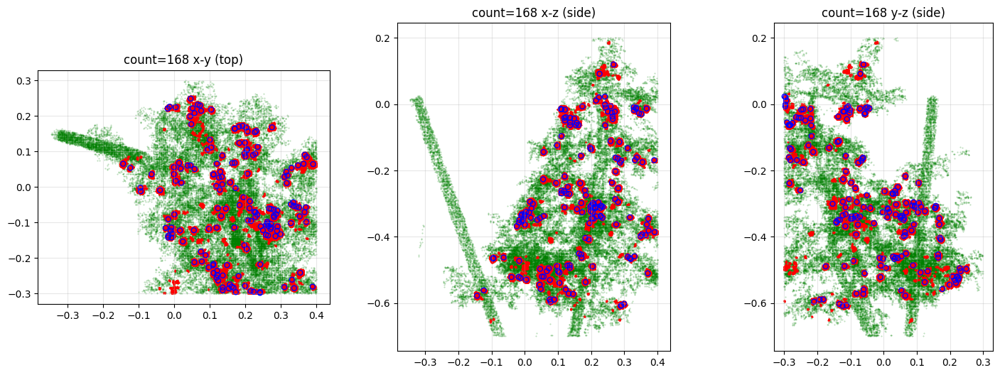

In [18]:
# ===== Cell 14: count + report
count, centers, info, p_filt, labels = count_fruits(pc["fruit_pts"], pc["spacing"], CFG)
key = next((k for k in GT_COUNTS if k in CFG["scene"].lower()), None)
if key:
    gt_n = GT_COUNTS[key]
    print(f"\nGT ({key}) = {gt_n} | predicted = {count} | error = {count - gt_n:+d} ({100 * (count - gt_n) / gt_n:+.1f}%)")
json.dump({**info, "tree": TREE, "scene": CFG["scene"], "preset": CFG["preset"], "semantic_dir": CFG["semantic_dir"],
           "gt": GT_COUNTS.get(key), "bbox_min": list(CFG["bbox_min"]), "bbox_max": list(CFG["bbox_max"]),
           "params": {k: CFG[k] for k in ("density_thr", "semantic_thr", "dbscan_eps_mult", "multi_mode", "export_res")}},
          open(RUN_DIR / "count.json", "w"), indent=2, default=float)
print("saved", RUN_DIR / "count.json")

cmap = plt.get_cmap("tab20")
cols = np.where(labels[:, None] >= 0, cmap(labels % 20)[:, :3], 0.5)
save_ply(RUN_DIR / "fruit_clusters.ply", p_filt, cols)
save_ply(RUN_DIR / "fruit_centers.ply", centers, np.tile([0.0, 0.0, 1.0], (len(centers), 1)))
plot_projections(pc["tree_pts"], p_filt, f"count={count}", centers=centers)
# If the count is off: tune dbscan_eps_mult / min_size_factor / multi_factor / fruit_diameter in CFG and re-run THIS cell only.

In [19]:
# ===== Cell 15: results table vs paper (all trees counted so far)
PAPER = {  # paper Fig. 8, total counts
    "semantics_sam":  {"fruit_nerf": {"tree_01": 147, "tree_02": 86, "tree_03": 190},
                       "fruit_nerf_big": {"tree_01": 173, "tree_02": 112, "tree_03": 264}},
    "semantics_unet": {"fruit_nerf": {"tree_01": 146, "tree_02": 88, "tree_03": 255},
                       "fruit_nerf_big": {"tree_01": 172, "tree_02": 114, "tree_03": 243}},
}
rows = []
for f in sorted(CFG["out_root"].glob("*/count.json")):
    r = json.load(open(f))
    t = r.get("tree") or next((k for k in ("tree_01", "tree_02", "tree_03") if k in r.get("scene", "")), None)
    if t is None or r.get("gt") is None:
        continue
    masks = r.get("semantic_dir") or "semantics_sam"
    rows.append((t, masks, r["preset"], r["gt"], PAPER.get(masks, {}).get(r["preset"], {}).get(t), r["count"]))
print(f"{'tree':8s} {'masks':15s} {'model':12s} {'GT':>4s} {'paper':>6s} {'paper%':>7s} {'ours':>5s} {'ours%':>6s}")
for t, m, pr, gt, pa, ours in rows:
    pp = f"{100 * pa / gt:5.1f}%" if pa else "    -  "
    print(f"{t:8s} {m:15s} {pr:12s} {gt:4d} {pa if pa else '-':>6} {pp:>7s} {ours:5d} {100 * ours / gt:5.1f}%")
print("\n(tree_02 was used to choose the counting params; tree_01 and tree_03 are the held-out test)")

tree     masks           model          GT  paper  paper%  ours  ours%
tree_01  semantics_sam   fruit_nerf    179    147   82.1%   168  93.9%
tree_02  semantics_sam   fruit_nerf    113     86   76.1%    98  86.7%

(tree_02 was used to choose the counting params; tree_01 and tree_03 are the held-out test)


In [20]:
base_min, base_max = np.array(CFG["bbox_min"]), np.array(CFG["bbox_max"])
for d in (-0.03, 0.0, 0.03):
    bmin, bmax = tuple(base_min - d), tuple(base_max + d)
    pc_ = export_point_clouds(model, bmin, bmax, CFG["export_res"], CFG["density_thr"], CFG["semantic_thr"], tree_keep_frac=0.0)
    n, *_ = count_fruits(pc_["fruit_pts"], pc_["spacing"], CFG, verbose=False)
    print(f"box {'shrunk' if d < 0 else 'grown' if d > 0 else 'as set'} by {abs(d):.2f}: count = {n}")

export:   0%|          | 0/512 [00:00<?, ?it/s]

box shrunk by 0.03: count = 141


export:   0%|          | 0/512 [00:00<?, ?it/s]

box as set by 0.00: count = 168


export:   0%|          | 0/512 [00:00<?, ?it/s]

box grown by 0.03: count = 179


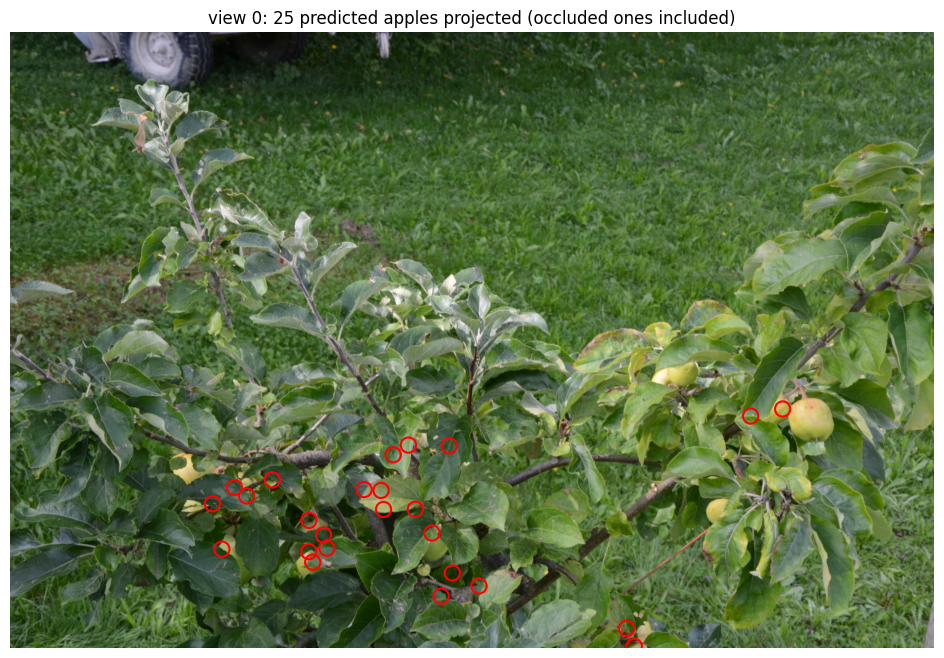

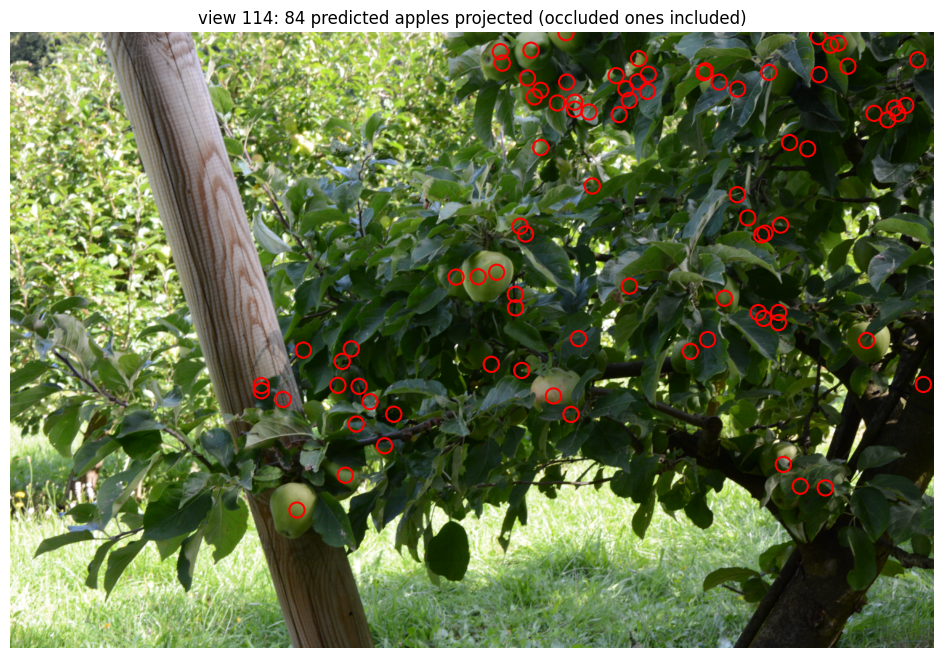

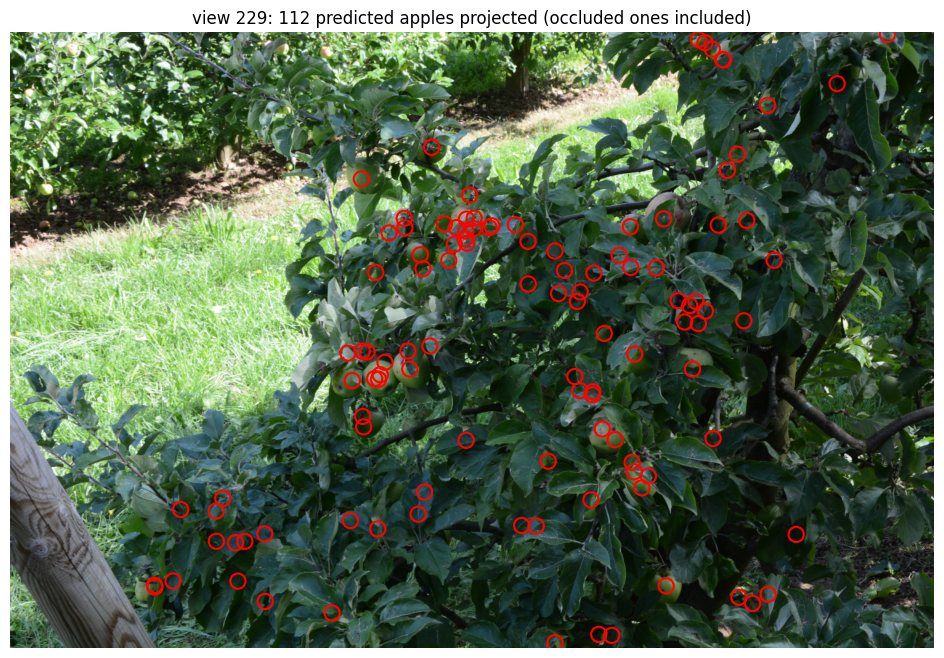

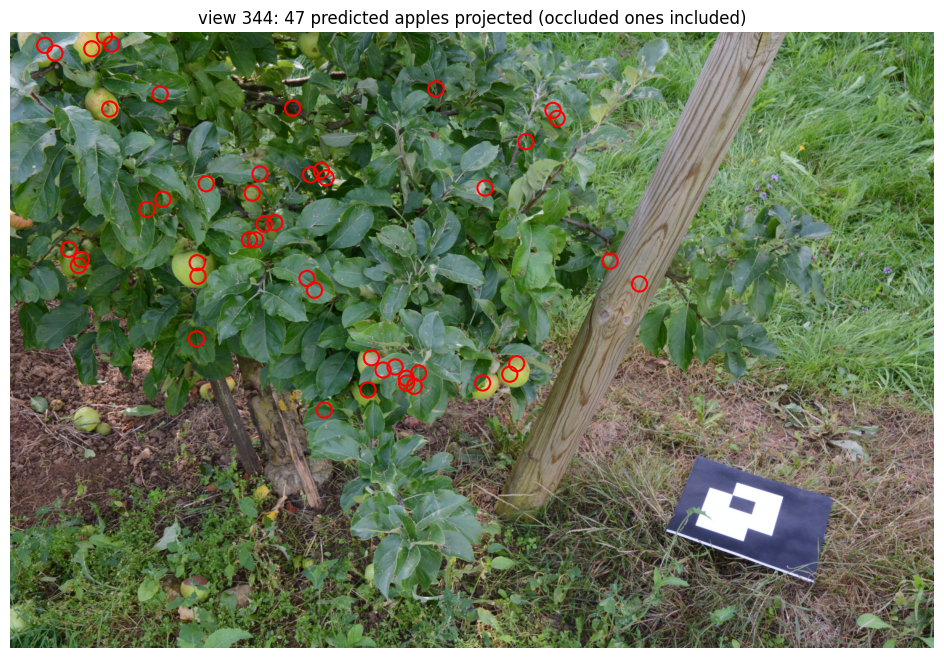

In [21]:
# ===== project predicted apple centres into photos (visual precision spot-check)
def project(centers, ds, idx):
    c2w = ds.c2w[idx].cpu().numpy(); K = ds.K[idx].cpu().numpy()
    R, t = c2w[:3, :3], c2w[:3, 3]
    pc_ = (centers - t) @ R                     # world -> camera (OpenGL)
    front = pc_[:, 2] < 0
    u = K[0] * (pc_[:, 0] / -pc_[:, 2]) + K[2] - 0.5
    v = K[1] * (-pc_[:, 1] / -pc_[:, 2]) + K[3] - 0.5
    ok = front & (u >= 0) & (u < ds.W) & (v >= 0) & (v < ds.H)
    return u[ok], v[ok]

for idx in np.linspace(0, ds.N - 1, 4).astype(int):
    u, v = project(centers, ds, idx)
    plt.figure(figsize=(12, 8)); plt.imshow(ds.images[idx].cpu().numpy())
    plt.scatter(u, v, s=120, facecolors="none", edgecolors="red", lw=1.5)
    plt.title(f"view {idx}: {len(u)} predicted apples projected (occluded ones included)"); plt.axis("off"); plt.show()

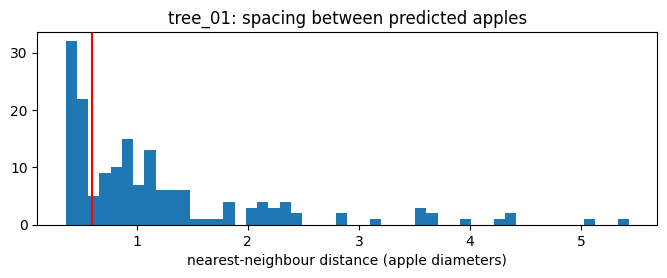

centres closer than 0.5 apple diameters:  22 pairs -> count after merging duplicates = 147
centres closer than 0.6 apple diameters:  36 pairs -> count after merging duplicates = 136
centres closer than 0.7 apple diameters:  40 pairs -> count after merging duplicates = 133


In [22]:
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix

d = CFG["fruit_diameter"]
kd = cKDTree(centers)
nn = kd.query(centers, k=2)[0][:, 1] / d
plt.figure(figsize=(8, 2.5)); plt.hist(nn, bins=50); plt.axvline(0.6, c="red")
plt.xlabel("nearest-neighbour distance (apple diameters)"); plt.title(f"{TREE}: spacing between predicted apples"); plt.show()

for thr in (0.5, 0.6, 0.7):
    pairs = np.array(list(kd.query_pairs(thr * d)))
    if len(pairs):
        g = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(centers),) * 2)
        n_merged = connected_components(g, directed=False)[0]
    else:
        n_merged = len(centers)
    print(f"centres closer than {thr:.1f} apple diameters: {len(pairs):3d} pairs -> count after merging duplicates = {n_merged}")

In [23]:
# ===== summary: prediction vs GT (same measure as the paper, Fig. 8)
res = [(t, gt, pa, ours) for t, m, pr, gt, pa, ours in rows if pr == "fruit_nerf" and m == "semantics_sam"]
print(f"{'tree':8s} {'GT':>4s} | {'paper':>5s} {'err':>5s} {'%':>6s} | {'ours':>5s} {'err':>5s} {'%':>6s}")
for t, gt, pa, ours in res:
    print(f"{t:8s} {gt:4d} | {pa:5d} {pa - gt:+5d} {100 * pa / gt:5.1f}% | {ours:5d} {ours - gt:+5d} {100 * ours / gt:5.1f}%")
mae_p = np.mean([abs(pa - gt) for _, gt, pa, _ in res]); mae_o = np.mean([abs(o - gt) for _, gt, _, o in res])
acc_p = np.mean([pa / gt for _, gt, pa, _ in res]) * 100; acc_o = np.mean([o / gt for _, gt, _, o in res]) * 100
print(f"\nmean abs error: paper {mae_p:.1f} | ours {mae_o:.1f}")
print(f"mean count/GT : paper {acc_p:.1f}% | ours {acc_o:.1f}%")

tree       GT | paper   err      % |  ours   err      %
tree_01   179 |   147   -32  82.1% |   168   -11  93.9%
tree_02   113 |    86   -27  76.1% |    98   -15  86.7%

mean abs error: paper 29.5 | ours 13.0
mean count/GT : paper 79.1% | ours 90.3%


In [24]:
# ===== duplicate-corrected counts (physical non-overlap rule, same threshold for every tree)
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix

MIN_SEP = 0.6   # apple diameters; from the gap in the spacing histogram, not from GT

def merge_close(cs, d, thr=MIN_SEP):
    pairs = np.array(list(cKDTree(cs).query_pairs(thr * d)))
    if len(pairs) == 0:
        return len(cs)
    g = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(cs),) * 2)
    return connected_components(g, directed=False)[0]

final = []
for f in sorted(CFG["out_root"].glob("*/count.json")):
    r = json.load(open(f)); folder = f.parent
    t = r.get("tree") or next((k for k in ("tree_01", "tree_02", "tree_03") if k in r.get("scene", "")), None)
    if t is None or not (folder / "clouds.npz").exists():
        continue
    z = np.load(folder / "clouds.npz")
    C = dict(CFG, fruit_diameter=r["fruit_diameter"])
    n_raw, cs, _, _, _ = count_fruits(z["fruit_pts"], float(z["spacing"]), C, verbose=False)
    n_ded = merge_close(cs, r["fruit_diameter"])
    r.update(count_raw=n_raw, count_dedup=n_ded, min_sep=MIN_SEP)
    json.dump(r, open(f, "w"), indent=2, default=float)
    final.append((t, r["gt"], n_raw, n_ded))

PAPER_SAM = {"tree_01": 147, "tree_02": 86, "tree_03": 190}
print(f"{'tree':8s} {'GT':>4s} | {'paper':>5s} {'%':>6s} | {'raw':>4s} {'%':>6s} | {'dedup':>5s} {'%':>6s}")
for t, gt, nr, nd in final:
    print(f"{t:8s} {gt:4d} | {PAPER_SAM[t]:5d} {100*PAPER_SAM[t]/gt:5.1f}% | {nr:4d} {100*nr/gt:5.1f}% | {nd:5d} {100*nd/gt:5.1f}%")

tree       GT | paper      % |  raw      % | dedup      %
tree_01   179 |   147  82.1% |  168  93.9% |   136  76.0%
tree_02   113 |    86  76.1% |  100  88.5% |    85  75.2%


In [25]:
# duplicate correction (physical non-overlap rule, same for every tree)
from scipy.sparse.csgraph import connected_components
from scipy.sparse import coo_matrix
MIN_SEP = 0.6
pairs = np.array(list(cKDTree(centers).query_pairs(MIN_SEP * CFG["fruit_diameter"])))
if len(pairs):
    g = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(centers),) * 2)
    count_dedup = connected_components(g, directed=False)[0]
else:
    count_dedup = len(centers)
print(f"raw = {count} | dedup = {count_dedup}" + (f" | GT = {GT_COUNTS[key]}" if key else ""))
r = json.load(open(RUN_DIR / "count.json")); r.update(count_raw=count, count_dedup=count_dedup, min_sep=MIN_SEP)
json.dump(r, open(RUN_DIR / "count.json", "w"), indent=2, default=float)

raw = 168 | dedup = 136 | GT = 179


In [26]:
# ===== counting v2: non-chaining duplicate suppression + recovery of isolated partial apples
# settings fixed in advance (not tuned on GT): min_sep = 0.6 d, tiny >= 20% of a typical apple, isolation = 1.0 d
def count_fruits_v2(pts, h, C, min_sep=0.6, tiny_min_frac=0.2, tiny_iso=1.0):
    n_raw, cs, info, p, labels = count_fruits(pts, h, C, verbose=False)
    d, v_t = info["fruit_diameter"], info["template_volume"]
    keep = []
    for c in cs:                                            # (1) suppression without chaining
        if all(np.linalg.norm(c - k) >= min_sep * d for k in keep):
            keep.append(c)
    n_nms = len(keep)
    ids = [k for k in np.unique(labels) if k >= 0]          # (2) recover isolated partial apples
    cl = [p[labels == k] for k in ids]
    vol = np.array([hull_volume(c) for c in cl]); npts = np.array([len(c) for c in cl])
    ratio = vol / max(v_t, 1e-12)
    is_single = (ratio >= C["min_size_factor"]) & (ratio <= C["multi_factor"])
    ref = np.median(npts[is_single]) if is_single.any() else np.median(npts)
    added = 0
    for i in np.where(ratio < C["min_size_factor"])[0]:
        if npts[i] < tiny_min_frac * ref:
            continue
        c = cl[i].mean(0)
        if keep and min(np.linalg.norm(c - k) for k in keep) < tiny_iso * d:
            continue
        keep.append(c); added += 1
    return len(keep), np.array(keep), dict(raw=n_raw, after_nms=n_nms, tiny_recovered=added)

PAPER_SAM = {"tree_01": 147, "tree_02": 86, "tree_03": 190}
print(f"{'tree':8s} {'GT':>4s} | {'paper':>5s} {'%':>6s} | {'v1 dedup':>8s} {'%':>6s} | {'v2':>4s} {'%':>6s} | nms  +tiny")
for f in sorted(CFG["out_root"].glob("*/count.json")):
    r = json.load(open(f)); folder = f.parent
    t = r.get("tree") or next((k for k in ("tree_01", "tree_02", "tree_03") if k in r.get("scene", "")), None)
    if t is None or not (folder / "clouds.npz").exists():
        continue
    z = np.load(folder / "clouds.npz")
    n2, cs2, i2 = count_fruits_v2(z["fruit_pts"], float(z["spacing"]), dict(CFG, fruit_diameter=r["fruit_diameter"]))
    gt, v1 = r["gt"], r.get("count_dedup")
    r.update(count_v2=n2, v2_info=i2); json.dump(r, open(f, "w"), indent=2, default=float)
    print(f"{t:8s} {gt:4d} | {PAPER_SAM[t]:5d} {100*PAPER_SAM[t]/gt:5.1f}% | {v1:8d} {100*v1/gt:5.1f}% | "
          f"{n2:4d} {100*n2/gt:5.1f}% | {i2['after_nms']:4d}  +{i2['tiny_recovered']}")

tree       GT | paper      % | v1 dedup      % |   v2      % | nms  +tiny
tree_01   179 |   147  82.1% |      136  76.0% |  148  82.7% |  139  +9
tree_02   113 |    86  76.1% |       85  75.2% |  104  92.0% |   86  +18
